# Libraries

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
from typing import Sequence, Optional

import matplotlib.pyplot as plt
from pathlib import Path

# Feature Engineering for the Energy Meta-Model

We chouse the four energy futures:

    CL1S  -- WTI Crude Oil
    HO1S  -- Heating Oil
    RB1S  -- RBOB Gasoline
    NG1S  -- Natural Gas

Design principles:
---------------------------
1. CAUSALITY. Every feature uses only data available at or before time t.
   - All rolling windows use the default `closed='right'`, i.e. they include
     t and the (window-1) prior bars. Never `center=True`.
   - No `.expanding().fit()` style global computations on the full series.
   - GMM / HMM / PCA must be fit *walk-forward*. We provide a utility for it.

2. DECISION-POINT ALIGNMENT. The metamodel must decide whether to follow
   the primary signal *for day t* based only on information known at the
   start of day t (i.e. at the close of day t-1). We therefore provide a
   helper `shift_features_for_decision(df)` that lags every feature by 1
   day. Call it once, at the very end, before training.

3. PER-INSTRUMENT GROUPING. All time-series operations are done with
   `groupby('instrument', group_keys=False).apply(...)` so we never let
   one instrument's data leak into another instrument's rolling window.

4. NO LEAKAGE FROM CROSS-ASSET FEATURES. Cross-asset features for
   instrument A on date t only use other instruments' OHLCV up to date t.

## Feature Catalogue

This notebook builds **~225 engineered features** across **20 clusters** for the metamodel, using the full 11-instrument universe.

The instruments are organised into three asset-class layers:
- **Energy (target)**: `cl1s`, `ho1s`, `rb1s`, `ng1s`
- **Metals (macro)**: `gc1s`, `si1s`, `hg1s`, `pl1s`
- **Equities (macro)**: `es1s`, `nq1s`, `fesx1s`

> ⚠️ **All features are causal.** At decision time *t*, each feature uses only OHLCV data observed up to (and including) the close of day *t-1*. This is enforced by the final `shift_features_for_decision(...)` call in the pipeline, and has been verified by a unit test that mutates future data and confirms no past feature value changes.

The 20 clusters below correspond directly to the cluster IDs used in the cluster-level feature importance analysis.

---

## 1. Returns & Path Diagnostics (Cluster: `returns`)

Describes the recent return distribution and how "stretched" the market is. A trend-following primary signal performs very differently depending on whether returns exhibit positive autocorrelation (momentum regime) or negative autocorrelation (mean-reverting regime).

| Feature | Definition | Interpretation |
|---|---|---|
| `log_ret_1` | $\ln(C_t / C_{t-1})$ | Most recent daily log return. Foundation for all higher-order features. |
| `log_ret_5`, `log_ret_10`, `log_ret_20`, `log_ret_60`, `log_ret_120` | Sum of `log_ret_1` over *n* days | Multi-horizon momentum. Captures persistence across weekly, monthly, quarterly scales. |
| `cum_ret_5`, ..., `cum_ret_120` | $\exp(\text{log\_ret}_n) - 1$ | Cumulative return in % terms; same information as log returns. |
| `ret_skew_20`, `ret_skew_60` | Rolling skewness of daily log returns | Negative skew → frequent small gains punctuated by large losses (crash risk); common in energy markets. |
| `ret_kurt_20`, `ret_kurt_60` | Rolling excess kurtosis (Fisher) | High kurtosis → fat tails. Trend signals in fat-tailed regimes face sudden reversal risk. |
| `ret_acf1_60`, `ret_acf2_60` | Rolling lag-1 / lag-2 autocorrelation over 60 days | **Direct momentum diagnostic.** Positive ACF1 → trends persist (good for trend signal). Negative → mean reversion. |
| `drawdown_60` | $C_t / \max_{[t-59,t]}(C) - 1$, always ≤ 0 | How far the price is from its rolling 60-day peak. Deep drawdowns often precede regime change. |
| `days_since_high_60` | Number of bars since the 60-day max | Time-dimension of the drawdown. Long durations → tired uptrend / bear regime. |
| `hurst_100` | Hurst exponent (R/S) over 100 days | **H > 0.5 trending; H < 0.5 mean-reverting; H = 0.5 random walk.** Directly tells the metamodel whether trend-following has edge. |
| `var_ratio_5_100` | Lo-MacKinlay variance ratio VR(5) over 100 days | $\text{Var}(r_5) / (5 \cdot \text{Var}(r_1))$. >1 → momentum; <1 → mean reversion. |

---

## 2. Volatility & Risk (Cluster: `volatility`)

Almost certainly the most important family for a commodities meta-model. We include several OHLC-based estimators because they are far more efficient than close-to-close standard deviation (Yang–Zhang can be up to 14× lower variance than close-to-close).

All annualised by $\sqrt{252}$.

| Feature | Definition | Interpretation |
|---|---|---|
| `realised_vol_5`, `realised_vol_20`, `realised_vol_60` | Annualised stdev of daily log returns over *w* days | Classic close-to-close realised volatility at short / medium / long horizons. |
| `parkinson_5/20/60` | $\sqrt{\frac{1}{4 \ln 2} \overline{\ln(H/L)^2}}$ | Range-based estimator. ~5× more efficient than close-to-close. |
| `gk_5/20/60` | Garman–Klass OHLC estimator | Uses all of OHLC; assumes zero drift. |
| `rs_5/20/60` | Rogers–Satchell estimator | **Drift-independent** — robust when prices trend. Important for commodities. |
| `yz_5/20/60` | Yang–Zhang estimator | Combines overnight gap + intraday RS. Best-in-class from OHLC alone. |
| `vol_ratio_5_20` | $\sigma_5 / \sigma_{20}$ | **Volatility regime change.** > 1 → vol expanding (often precedes trend breakdown). |
| `vol_of_vol_60` | Stdev of `realised_vol_20` over last 60 days | High vol-of-vol → unstable regime; metamodel should be more cautious. |
| `semi_vol_down_5/20/60` | Stdev of *negative* returns only | Downside risk (Sortino numerator). |
| `semi_vol_up_5/20/60` | Stdev of *positive* returns only | Upside variability. |
| `vol_asym_5/20/60` | $(\sigma_{\text{up}} - \sigma_{\text{down}}) / \sigma_{\text{total}}$ | Positive → upside dominates; negative → downside dominates. Negative readings often warn of crashes. |
| `atr_14`, `atr_20` | Wilder's Average True Range | Trade-friendly risk measure; basis for triple-barrier widths. |
| `atr_pct_14`, `atr_pct_20` | ATR / close | Dimensionless, comparable across instruments. |
| `bb_width_20` | $(BB_{\text{up}} - BB_{\text{low}}) / SMA_{20}$ | Bollinger bandwidth. Tight bands → low vol; expansion often precedes breakouts. |
| `bb_pctB_20` | $(C - BB_{\text{low}}) / (BB_{\text{up}} - BB_{\text{low}})$ | Where the close sits in the bands. >1 = above upper, <0 = below lower. |

---

## 3. Trend Strength (Cluster: `trend`)

Since the primary signal is trend-style, these directly proxy "is there a trend worth following today?" — exactly the question the metamodel should be answering.

| Feature | Definition | Interpretation |
|---|---|---|
| `price_to_sma_10/20/50/100/200` | $C_t / SMA_w - 1$ | Distance from moving average, in %. Stationary, model-friendly substitute for raw price. |
| `sma_{w}_slope` (w ∈ {10,20,50,100,200}) | 5-bar pct-change of SMA | MA slope. Sign tells direction; magnitude tells strength. |
| `ma_cross_20_50` | $\text{sign}(\text{price\_to\_sma}_{20} - \text{price\_to\_sma}_{50})$ | +1 if 20-SMA above 50-SMA (golden-cross territory), −1 otherwise. |
| `ma_cross_50_200` | $\text{sign}(\text{price\_to\_sma}_{50} - \text{price\_to\_sma}_{200})$ | Long-term trend regime flag. |
| `donchian_pos_20`, `donchian_pos_55` | $(C - L_w) / (H_w - L_w)$ | Position within rolling high–low channel. Classic Turtle indicator. |
| `kaufman_er_10`, `kaufman_er_20` | $\|C_t - C_{t-w}\| / \sum \|C_i - C_{i-1}\|$ | **Trend efficiency.** ER ≈ 1 smooth trend; ER ≈ 0 choppy. |
| `trend_r2_20`, `trend_r2_60` | $R^2$ from regressing close on time index | "Trend quality": high R² → clean linear move. |
| `plus_di_14`, `minus_di_14` | Wilder's directional indicators | Building blocks of ADX. |
| `adx_14` | Average Directional Index (Wilder) | **The** classic trend-strength indicator. >25 trending; <20 ranging. |
| `aroon_up_25`, `aroon_down_25` | $100 \cdot (\text{argmax} / w)$ | How recently the period high/low was set. |
| `aroon_osc_25` | Aroon Up − Aroon Down | Net trend strength, range [−100, 100]. |

---

## 4. Oscillators & Mean Reversion (Cluster: `oscillators`)

The same indicators flip meaning depending on regime: RSI 80 in a strong uptrend = continuation; in a range = overbought.

| Feature | Definition | Interpretation |
|---|---|---|
| `rsi_14`, `rsi_28` | Wilder's Relative Strength Index | >70 overbought, <30 oversold. Most-used oscillator in commodities. |
| `stoch_k_14` | $100 \cdot (C - L_{14}) / (H_{14} - L_{14})$ | Position in last 14-day range. |
| `stoch_d_14` | 3-day SMA of `stoch_k_14` | Smoothed signal line. |
| `macd` | $EMA_{12}(C) - EMA_{26}(C)$ | Trend + momentum hybrid. |
| `macd_signal` | $EMA_9(\text{macd})$ | Signal line. |
| `macd_hist` | macd − macd_signal | Sign change → momentum reversal. |
| `macd_norm`, `macd_signal_norm`, `macd_hist_norm` | Above divided by close | **Use these** — the unnormalised versions are non-stationary across price levels. |
| `cci_20` | Commodity Channel Index, 20-day | **Designed for commodities.** \|CCI\| > 100 → outside typical range. |
| `williams_r_14` | $-100 \cdot (H_{14} - C) / (H_{14} - L_{14})$ | > −20 overbought, < −80 oversold. |
| `price_zscore_20`, `price_zscore_60` | $(C - SMA_w) / \sigma_w$ | Stationary "how far is price from its mean". |

---

## 5. Volume & Open Interest (Cluster: `volume_oi`)

**Heavily under-used in equity-only studies but crucial in futures.** Rising OI confirms a trend (new positions opening); falling OI during a price move signals short-covering or long-liquidation (low conviction).

| Feature | Definition | Interpretation |
|---|---|---|
| `volume_z_20`, `volume_z_60` | Z-score of volume vs rolling mean | Volume-spike detector. |
| `volume_roc_20`, `volume_roc_60` | Volume / rolling_mean − 1 | Rate of change in trading activity. |
| `obv` | Cumulative signed volume (Granville) | Non-stationary — included for completeness; use `obv_slope_20` instead. |
| `obv_slope_20` | 20-day diff of OBV, scaled by its rolling stdev | OBV momentum. |
| `amihud_20` | $\overline{\|r\| / \text{volume}}$ over 20 days | Illiquidity proxy. High → moves require less volume → fragile market. |
| `oi_z_20`, `oi_z_60` | Z-score of open interest | Position-building intensity. |
| `oi_roc_20`, `oi_roc_60` | OI / OI.shift(w) − 1 | Pct change in OI. |
| `oi_to_vol_20` | OI / mean(volume, 20) | Position-vs-flow ratio. High = patient money; low = day-trader flow. |
| `mfi_14` | Money Flow Index | Volume-weighted RSI on typical price. |
| `oi_price_divergence_20` | $\text{sign}(\sum r_{20}) \cdot \text{sign}(\text{oi\_roc}_{20})$ | **Textbook commodity signal.** +1: price ↑ with OI ↑ → strong trend. −1: price ↑ with OI ↓ → short-covering (weak). |

---

## 6. Candlestick & Microstructure (Cluster: `microstructure`)

OHLC contains more than just close-to-close information.

| Feature | Definition | Interpretation |
|---|---|---|
| `range_pct` | $(H - L) / C$ | Daily range as fraction of close. |
| `body_to_range` | $\|C - O\| / (H - L)$ | Small body in big range = indecision (doji). |
| `upper_shadow_pct` | $(H - \max(O,C)) / (H - L)$ | Large = sellers rejected highs. |
| `lower_shadow_pct` | $(\min(O,C) - L) / (H - L)$ | Large = buyers rejected lows. |
| `range_expansion_20` | $(H-L)_t / \overline{(H-L)}_{20}$ | >2 → notable range expansion. |
| `gap_pct` | $(O_t - C_{t-1}) / C_{t-1}$ | Overnight gap; significant in oil markets. |
| `clv` | $((C - L) - (H - C)) / (H - L)$ | **Close Location Value** ∈ [−1, +1]. |
| `inside_days_10` | Count of inside days in last 10 | High = consolidation, often precedes breakout. |
| `outside_days_10` | Count of outside days in last 10 | High = volatility / regime change. |

---

## 7. Latent Regime — Per-Instrument (Cluster: `regime_latent`)

**Directly from Lectures 2 and 3.** Fitted walk-forward (refit every 60–120 days) on each instrument's (return, vol) pair to avoid look-ahead bias.

| Feature | Definition | Interpretation |
|---|---|---|
| `gmm_post_0`, `gmm_post_1`, `gmm_post_2` | Posteriors from a 3-component GMM fit on (log return, realised vol) | Soft regime assignment. Components typically capture calm / normal / turbulent. |
| `gmm_mahalanobis_to_top` | Mahalanobis distance to centroid of highest-prob component | **Per-instrument turbulence indicator** (Chow–Kritzman style, Lecture 3). |
| `hmm_state_0`, `hmm_state_1`, `hmm_state_2` | **Filtered** posteriors $P(H_t = k \mid x_{1:t})$ from a 3-state Gaussian HMM | Current regime using only past data (forward algorithm — *not* smoothed, which would leak). |
| `hmm_next_state_0/1/2` | $P(H_{t+1} = k \mid x_{1:t}) = \alpha_t \cdot A$ | **Forward-looking** regime forecast. Exactly what the metamodel needs. |

---

## 8. Cross-Asset / Energy Complex (Cluster: `cross_asset`)

The four energy futures are economically linked through the refining complex. Cross-asset features add genuine information that single-instrument features cannot.

| Feature | Definition | Interpretation |
|---|---|---|
| `corr_{a}_{b}_{20/60}` (all energy pairs) | Rolling pairwise return correlations | High → complex moving together (macro driver). Low → idiosyncratic. |
| `crack_ho_cl_logratio`, `crack_ho_cl_z_60` | $\ln(P_{HO}/P_{CL})$ and 60d z-score | **Heating oil crack spread.** Refining margin proxy. |
| `crack_rb_cl_logratio`, `crack_rb_cl_z_60` | Same for gasoline | Gasoline crack spread. |
| `crack_321_logspread`, `crack_321_z_60` | $2\ln P_{CL} - \ln P_{HO} - \ln P_{RB}$ + z-score | **3-2-1 crack proxy** — classic refining margin used by every commodity desk. |
| `beta_{cl/ho/rb/ng}1s_vs_cl_60` | Rolling 60d beta vs CL | How much each instrument moves with crude. `beta_cl1s_vs_cl_60 ≡ 1` (sanity check). |
| `energy_pc1` | First principal component of the 4 energy returns (rolling 120d fit) | The common "energy factor". |
| `idio_resid_{cl/ho/rb/ng}1s` | Today's return − projection on PC1 | **Idiosyncratic return** — what's left after removing common factor. |
| `energy_xs_dispersion` | Cross-sectional stdev of energy returns today | High → complex fragmenting (regime change signal). |
| `equity_vol_20` | 20-day annualised vol of ES1S | First-pass VIX-style proxy (see also `vix_proxy_avg` in cluster 13). |
| `equity_dd_60` | ES1S close / rolling 60d max − 1 | Equity-market drawdown. |
| `gold_minus_equity_20` | 20d return GC − 20d return ES | Flight-to-safety indicator. |
| `copper_gold_ret_diff_60` | 60d return HG − 60d return GC | Classical macro growth proxy (also see cluster 12). |

---

## 9. Calendar / Seasonality (Cluster: `seasonality`)

Energy markets have well-documented and economically driven seasonality. These features are **not** shifted to t-1 because the calendar position of day *t* is genuinely known on day *t*.

| Feature | Definition | Interpretation |
|---|---|---|
| `month_sin`, `month_cos` | Sin/cos of month (period 12) | Preserves cyclical distance: Dec and Jan are adjacent. |
| `dow_sin`, `dow_cos` | Sin/cos of day-of-week (period 5) | Captures intraweek patterns. |
| `heating_season` | 1 if month ∈ {Nov–Mar} | Heating-fuel demand → HO, NG. |
| `driving_season` | 1 if month ∈ {Apr–Sep} | US summer driving → gasoline (RB) demand. |
| `hurricane_season` | 1 if month ∈ {Jun–Nov} | Gulf Coast supply disruption risk for CL, RB, NG. |
| `days_to_month_end` | Calendar days until month end | Roll / settlement effects. |
| `day_of_month` | Day of month (1–31) | Index-rebalancing flows around month-end. |

---

## 10. Primary-Signal Context (Cluster: `signal_context`)

Features describing the *situation around* the primary signal itself.

| Feature | Definition | Interpretation |
|---|---|---|
| `primary_signal` | The signal being meta-labelled, ∈ {−1, 0, +1} | **The input the metamodel is qualifying.** |
| `signal_run_length` | Consecutive days with the same signal | Long run → persistent regime; very long → possible exhaustion. |
| `signal_flip_rate_20` | Fraction of last 20 days where signal changed | High → choppy regime where signal whipsaws. |
| `days_since_signal_change` | Bars since last signal change | Persistence measure. |
| `signal_rolling_pnl_20` | Rolling 20d "PnL" of following the signal (signal × next-day return) | **Primary signal's recent track record.** Crucial regime-conditional feature. |
| `signal_rolling_hit_60` | 60d hit rate of the primary signal | Empirical recent probability of profit. |

---

## 11. Information-Theoretic / Non-Linear (Cluster: `entropy`)

| Feature | Definition | Interpretation |
|---|---|---|
| `perm_entropy_60` | Normalised permutation entropy of last 60 returns (Bandt–Pompe, m=3) | Predictability of the path. **Low** = structured; **high** = noise-like. |

---

## 12. Metals Complex (Cluster: `metals_macro`)

**NEW cluster**, unlocked by the full universe. The four metals split into **precious** (GC, SI, PL) and **industrial** (HG). Relative performance is one of the cleanest macro-regime signals.

| Feature | Definition | Interpretation |
|---|---|---|
| `gold_silver_ratio_log` | $\ln(P_{GC} / P_{SI})$ | Classic risk-aversion gauge. Rising → flight to safety → typically bearish for oil. |
| `gold_silver_ratio_z_60` | 60-day z-score | Mean-reverts; extremes mark regime extremes. |
| `copper_gold_ratio_log` | $\ln(P_{HG} / P_{GC})$ | **Dr. Copper / Mr. Gold** — the most-watched macro growth signal. High → growth optimism → bullish energy demand. |
| `copper_gold_ratio_z_120` | 120-day z-score | Detects stretched growth expectations. |
| `platinum_gold_ratio_log` | $\ln(P_{PL} / P_{GC})$ | Auto-catalyst link to gasoline demand. The post-2015 inversion is a structural growth signal. |
| `platinum_gold_ratio_z_120` | 120-day z-score | |
| `silver_gold_beta_60` | Rolling beta of SI returns on GC returns | When β rises, silver decouples from precious-metal status and trades industrial. |
| `metals_pc1` | First PC of (GC, SI, HG, PL) returns, rolling 120d | The common "metals factor". |
| `metals_dispersion` | Cross-sectional stdev of metals returns today | High → market fragmenting (precious vs industrial divergence). |
| `precious_vs_industrial` | mean(GC, SI, PL returns) − HG return | Direct safe-haven-vs-growth measure. |

---

## 13. Equity Complex (Cluster: `equity_macro`)

Three equity indices give US-vs-Europe and broad-vs-tech dimensions.

| Feature | Definition | Interpretation |
|---|---|---|
| `equity_vol_es_20`, `equity_vol_nq_20`, `equity_vol_fesx_20` | 20-day annualised vol of each equity index | Three regional vol regimes. |
| `nq_es_ret_diff_20` | 20-day return: NQ − ES | **Tech vs broad-market** divergence. Tech leadership often = late-cycle = energy underperforms. |
| `fesx_es_ret_diff_20` | 20-day return: FESX − ES | **Europe vs US** equity divergence. Relevant for heating-oil demand. |
| `equity_vol_us_eu_ratio` | $\sigma_{ES} / \sigma_{FESX}$ | Where the equity stress is concentrated. |
| `equity_pc1` | First PC of (ES, NQ, FESX) returns, rolling 120d | Common global equity factor. |
| `vix_proxy_avg` | Mean of 20-day realised vol across the three indices | **Composite VIX-style proxy.** Strong cross-asset risk-on/off indicator. |
| `equity_max_drawdown_60` | Worst drawdown among the three indices over 60d | Any-region equity stress. |
| `equity_breadth_neg_60` | Fraction of equity indices in >5% drawdown | Risk-off breadth indicator. |

---

## 14. Cross-Complex Correlations (Cluster: `cross_complex`)

Correlations *between* asset classes change regime, and that's exactly the kind of context a metamodel exists for.

| Feature | Definition | Interpretation |
|---|---|---|
| `corr_cl1s_es1s_60` | Rolling 60d correlation: CL vs ES | **Critical regime indicator.** Historically ~+0.3 (growth story); spikes to >+0.5 in macro stress. |
| `corr_cl1s_gc1s_60` | CL vs gold correlation | Negative usually (dollar-driven); positive → inflation-trade regime. |
| `corr_cl1s_hg1s_60` | CL vs copper correlation | Both growth-sensitive; high correlation = pure macro regime. |
| `corr_cl1s_nq1s_60` | CL vs Nasdaq correlation | Captures tech-driven risk-off contagion. |
| `corr_complex_es_60` | Mean of (corr_{energy_i}_es) for i in {cl, ho, rb, ng} | **Composite energy-vs-equity coupling.** |
| `corr_complex_hg_60` | Mean of (corr_{energy_i}_hg) | Composite energy-vs-industrial-metals coupling. |
| `oil_dollar_proxy_60` | Rolling 60d corr of CL with (gold − equity) returns | Crude approximation of oil's USD-sensitivity (no DXY available). |

---

## 15. Within-Complex Spreads (Cluster: `spreads`)

Beyond cracks, the heating-oil-vs-gasoline and oil-gas spreads are economically meaningful and mean-reverting.

| Feature | Definition | Interpretation |
|---|---|---|
| `ho_rb_spread_log` | $\ln(P_{HO} / P_{RB})$ | **HO vs RB.** Reflects seasonal demand shift; mean-reverts. |
| `ho_rb_spread_z_60` | 60d z-score | Seasonal/cyclical extremes. |
| `ng_cl_ratio_log` | $\ln(P_{NG} / P_{CL})$ | **Oil-gas ratio.** Historic 6:1 rule; massive divergence post-2010 (shale). Still informative for rotations. |
| `ng_cl_ratio_z_120` | 120d z-score | NG vs oil relative-value extremes. |
| `crack_321_vol_60` | 60d stdev of daily change in 3-2-1 crack | **Refining-margin volatility.** High = uncertain demand/supply environment. |
| `crack_321_momentum_20` | 20d change in 3-2-1 crack | Refining margin trend — independent of outright price. |

---

## 16. Lead-Lag (Cluster: `leadlag`)

CL leads HO, RB, NG. Copper and equities can lead oil at macro horizons. All lags are strictly shifted into the past — no look-ahead.

| Feature | Definition | Use |
|---|---|---|
| `cl_lag1_ret`, `cl_lag2_ret`, `cl_lag5_ret` | CL log returns at lags 1, 2, 5 | Direct lagged-CL feature for HO, RB, NG metamodels. |
| `es_lag1_ret`, `es_lag5_ret` | ES log returns at lags 1, 5 | Risk-on/off lead indicator. |
| `hg_lag5_ret`, `hg_lag20_ret` | Copper lagged returns | Copper as a leading growth indicator. |
| `cl_es_leadlag_corr_60` | Rolling corr of CL_t with ES_{t-1} | Detects when equities are leading oil (macro-driven regime). |

---

## 17. Cross-Sectional Ranking (Cluster: `cross_section`)

Position of the target instrument **within the 11-asset universe** on each date. Cross-sectional features are robust because they're invariant to common factors.

| Feature | Definition | Interpretation |
|---|---|---|
| `xs_rank_ret_20` | Today's percentile rank of instrument's 20d return in the universe | Cross-sectional momentum percentile (1 = strongest of 11). |
| `xs_zscore_ret_20` | (20d return − universe mean) / universe stdev | How extreme is this instrument's move relative to the universe? |
| `xs_rank_vol_20` | Percentile rank of `realised_vol_20` in the universe | "Am I one of the more volatile names today?" |
| `xs_zscore_vol_20` | Z-score of vol vs universe | Idiosyncratic vol indicator. |
| `xs_rank_volume_z` | Percentile rank of `volume_z_20` across the universe | Liquidity/attention ranking. |
| `xs_top_quintile_flag` | 1 if `xs_rank_ret_20` > 0.8, else 0 | Crowded-momentum-trade flag. |
| `n_assets_in_drawdown` | Count of the 11 in >5% rolling 60d drawdown today | Universe-wide stress indicator. |
| `xs_corr_dispersion_proxy_60` | Cross-sectional stdev of 20d returns across universe | Low → "everything correlated" → systemic regime. |

---

## 18. Universe Vol Regime (Cluster: `vol_regime`)

Universe-wide vol features: "When global vol is up, the primary signal behaves differently" is exactly the kind of conditioning the metamodel needs.

| Feature | Definition | Interpretation |
|---|---|---|
| `mean_vol_universe_20` | Average of `realised_vol_20` across all 11 | **Global vol regime indicator.** Strong cross-asset feature. |
| `vol_dispersion_universe` | Stdev of `realised_vol_20` across the universe | High → some markets calm, others stressed (fragmented regime). |
| `energy_vol_premium` | mean(energy vols) − mean(non-energy vols) | When energy vol exceeds macro vol, idiosyncratic shock is in play. |
| `vol_persistence_120` | AR(1) coefficient of `realised_vol_20` in 120d window | Vol clustering strength (per-instrument). |
| `vol_correlation_60` | Rolling 60d corr of own vol with mean universe vol | How "marched-in-step" is this instrument with universe vol? |

---

## 19. Universe Turbulence (Cluster: `regime_universe`)

Chow–Kritzman financial turbulence at universe level.

| Feature | Definition | Interpretation |
|---|---|---|
| `turbulence_universe` | $\sqrt{(r_t - \mu)^T \Sigma^{-1} (r_t - \mu)}$ where $\mu, \Sigma$ are computed on returns over $[t-252, t-1]$ (excludes today) | **Classical financial turbulence index** computed jointly across all 11 instruments. Detects when today's joint return vector is anomalous relative to its rolling distribution. |
| `turbulence_change` | Day-on-day change in `turbulence_universe` | Regime-transition indicator. Sharp positive changes mark crisis onset. |

---

## 20. Engineered Interactions (Cluster: `interactions`)

Hand-crafted interactions motivated by trading intuition. Tree models can find interactions on their own, but explicit interactions help linear/logistic models and improve cluster-level SHAP interpretability.

| Feature | Definition | Rationale |
|---|---|---|
| `risk_on_trend_strength` | `adx_14` × (1 − \|`equity_dd_60`\|) | Trend strength weighted by risk-on context. |
| `oil_demand_proxy` | `copper_gold_ratio_z_120` × `equity_pc1` | Composite growth signal — both metals AND equities saying "growth". |
| `crack_compression_signal` | `crack_321_z_60` × `range_expansion_20` | Crack-spread extreme combined with vol expansion = potential reversal. |
| `dispersion_vol_combo` | `energy_xs_dispersion` × `vol_dispersion_universe` | Both intra- and inter-complex fragmentation. |
| `signal_in_stress` | `primary_signal` × `n_assets_in_drawdown` | Lets metamodel learn "trust the signal more (or less) during systemic stress". |
| `signal_in_high_corr` | `primary_signal` × `corr_complex_es_60` | "Trust the signal when energy is decoupled from equities." |
| `signal_in_turbulence` | `primary_signal` × `turbulence_universe` | Adjusts confidence in the primary signal during turbulent regimes. |

---

## Cluster summary for Section 4 (cluster-level feature importance)

The 20 clusters above map directly onto these IDs for the MDI / MDA / SHAP cluster-level analysis:

| ID | Cluster name | ~# features | Source |
|---|---|---|---|
| 1 | `returns` | 20 | Single-instrument |
| 2 | `volatility` | 26 | Single-instrument |
| 3 | `trend` | 21 | Single-instrument |
| 4 | `oscillators` | 13 | Single-instrument |
| 5 | `volume_oi` | 13 | Single-instrument |
| 6 | `microstructure` | 9 | Single-instrument |
| 7 | `regime_latent` | 10 | GMM/HMM per-instrument |
| 8 | `cross_asset` | 23 | Energy complex |
| 9 | `seasonality` | 9 | Calendar |
| 10 | `signal_context` | 6 | Primary signal |
| 11 | `entropy` | 1 | Non-linear |
| 12 | `metals_macro` | 10 | metals universe |
| 13 | `equity_macro` | 8 | equity universe |
| 14 | `cross_complex` | 7 | between asset classes |
| 15 | `spreads` | 6 | within energy complex |
| 16 | `leadlag` | 8 | lagged macro leaders |
| 17 | `cross_section` | 8 | universe ranking |
| 18 | `vol_regime` | 5 | universe vol |
| 19 | `regime_universe` | 2 | universe turbulence |
| 20 | `interactions` | 7 | engineered |
| | **Total model features** | **≈ 212** | (excluding OHLCV inputs and `primary_signal`) |

## SECTION 1 -- RETURN-BASED FEATURES
These describe the recent return distribution. They are the foundation of almost every other family below.

In [2]:
def add_return_features(df: pd.DataFrame,
                        horizons: Sequence[int] = (1, 5, 10, 20, 60, 120)
                        ) -> pd.DataFrame:
    """
    Multi-horizon log returns + distributional moments.

    Features added (per instrument, all causal):
      log_ret_1, log_ret_5, ...   -- log-return over n days (close_t/close_{t-n})
      cum_ret_n                   -- simple cumulative return over n days
      ret_skew_20, ret_skew_60    -- rolling skewness of daily log returns
      ret_kurt_20, ret_kurt_60    -- rolling excess kurtosis (Fisher)
      ret_acf1_60, ret_acf2_60    -- rolling lag-1, lag-2 autocorrelation
      drawdown_60                 -- (close / rolling_60d_max) - 1, <= 0
      days_since_high_60          -- bars since the rolling 60d max was set

    Why these matter for a META-model:
      A trend-following primary signal performs differently in regimes
      with positive vs. negative autocorrelation; skew/kurtosis hint at
      tail risk; drawdowns encode "how stretched" the market already is.
    """
    df = df.copy()
    df['log_ret_1'] = np.log(df['close'] / df.groupby('instrument')['close'].shift(1))

    for h in horizons:
        if h == 1:
            continue
        df[f'log_ret_{h}'] = (
            df.groupby('instrument')['log_ret_1']
              .rolling(h, min_periods=h).sum().reset_index(level=0, drop=True)
        )
        df[f'cum_ret_{h}'] = np.expm1(df[f'log_ret_{h}'])

    # Distributional moments of daily log returns
    for w in (20, 60):
        df[f'ret_skew_{w}'] = (
            df.groupby('instrument')['log_ret_1']
              .rolling(w, min_periods=w).skew().reset_index(level=0, drop=True)
        )
        df[f'ret_kurt_{w}'] = (
            df.groupby('instrument')['log_ret_1']
              .rolling(w, min_periods=w).kurt().reset_index(level=0, drop=True)
        )

    # Rolling autocorrelations -- distinguish momentum vs mean-revert regimes
    def _rolling_acf(s: pd.Series, lag: int, window: int) -> pd.Series:
        # Pearson corr between s and s.shift(lag), computed in a rolling window.
        # Causal: at time t we use observations [t-window+1, ..., t].
        return s.rolling(window, min_periods=window).corr(s.shift(lag))

    df['ret_acf1_60'] = df.groupby('instrument')['log_ret_1'].apply(
        lambda s: _rolling_acf(s, lag=1, window=60)).reset_index(level=0, drop=True)
    df['ret_acf2_60'] = df.groupby('instrument')['log_ret_1'].apply(
        lambda s: _rolling_acf(s, lag=2, window=60)).reset_index(level=0, drop=True)

    # Drawdown features
    for w in (60,):
        roll_max = df.groupby('instrument')['close'].transform(
            lambda s: s.rolling(w, min_periods=1).max()
        )
        df[f'drawdown_{w}'] = df['close'] / roll_max - 1.0

        # Days since the rolling max was reached. Implemented per-instrument.
        def _days_since_max(s: pd.Series) -> pd.Series:
            out = np.empty(len(s)); out[:] = np.nan
            vals = s.values
            for i in range(len(s)):
                start = max(0, i - w + 1)
                window_vals = vals[start:i+1]
                if len(window_vals) == 0 or np.all(np.isnan(window_vals)):
                    continue
                out[i] = (len(window_vals) - 1) - int(np.nanargmax(window_vals))
            return pd.Series(out, index=s.index)

        df[f'days_since_high_{w}'] = (
            df.groupby('instrument')['close']
              .apply(_days_since_max).reset_index(level=0, drop=True)
        )

    return df

In [3]:
def add_hurst_and_variance_ratio(df: pd.DataFrame,
                                 window: int = 100,
                                 vr_k: int = 5) -> pd.DataFrame:
    """
    Hurst exponent (R/S) and Lo-MacKinlay variance ratio.

    Both diagnose deviation from a random walk:
      Hurst > 0.5  -> trending     (good for the primary signal)
      Hurst < 0.5  -> mean-revert  (the primary signal should be filtered)
      VR(k) > 1    -> positive autocorrelation
      VR(k) < 1    -> mean reversion

    Implementation note: we use a simple R/S estimator. It is noisy at
    short windows; we use window=100 by default. Strictly causal -- the
    estimator at time t uses only returns in [t-window+1, ..., t].
    """
    df = df.copy()

    def _hurst_rs(returns: np.ndarray) -> float:
        # Standard rescaled-range estimator on log-returns.
        # Returns NaN if the window contains NaNs or is too short.
        if np.any(~np.isfinite(returns)) or len(returns) < 20:
            return np.nan
        N = len(returns)
        mean = returns.mean()
        Y = np.cumsum(returns - mean)
        R = Y.max() - Y.min()
        S = returns.std(ddof=1)
        if S == 0 or R == 0:
            return np.nan
        return np.log(R / S) / np.log(N)

    def _per_instrument(g: pd.DataFrame) -> pd.DataFrame:
        r = g['log_ret_1'].values
        hurst = np.full(len(r), np.nan)
        vr    = np.full(len(r), np.nan)
        for i in range(window - 1, len(r)):
            w = r[i - window + 1 : i + 1]
            if np.any(~np.isfinite(w)):
                continue
            hurst[i] = _hurst_rs(w)
            # Variance ratio:   var(sum of k consecutive returns) / (k * var(r))
            k = vr_k
            if window >= 2 * k:
                v1 = np.var(w, ddof=1)
                k_sums = np.array([w[j:j+k].sum() for j in range(len(w)-k+1)])
                vk = np.var(k_sums, ddof=1)
                vr[i] = vk / (k * v1) if v1 > 0 else np.nan
        out = pd.DataFrame({f'hurst_{window}': hurst,
                            f'var_ratio_{k}_{window}': vr},
                           index=g.index)
        return out

    extra = (df.groupby('instrument', group_keys=False)
               .apply(_per_instrument))
    df = pd.concat([df, extra], axis=1)
    return df

## SECTION 2 -- VOLATILITY FEATURES 
Probably the single most important family for a commodities meta-model. We include several OHLC-based estimators because they are much more efficient than close-to-close stdev (lower variance for the same data).

In [4]:
def add_volatility_features(df: pd.DataFrame,
                            windows: Sequence[int] = (5, 20, 60)) -> pd.DataFrame:
    """
    Realised vol + Parkinson, Garman-Klass, Rogers-Satchell, Yang-Zhang,
    semi-variance, ATR, Bollinger bandwidth.

    Annualisation uses 252 trading days.

    Key features:
      realised_vol_{w}    -- close-to-close annualised stdev of log returns
      parkinson_{w}       -- Parkinson high-low estimator
      gk_{w}              -- Garman-Klass OHLC estimator
      rs_{w}              -- Rogers-Satchell (drift-independent)
      yz_{w}              -- Yang-Zhang (overnight + intraday combined; best
                              from OHLC alone)
      vol_ratio_5_20      -- short/long vol ratio (expansion vs contraction)
      vol_of_vol_60       -- stdev of 20d realised vol over last 60 days
      semi_vol_down_{w}   -- downside semi-deviation (negative returns only)
      vol_asym_{w}        -- (semi_up - semi_down) / total_vol
      atr_{w}             -- Average True Range (Wilder)
      atr_pct_{w}         -- ATR / close, dimensionless
      bb_width_{w}        -- (upper_band - lower_band) / middle_band
    """
    df = df.copy()
    ANN = np.sqrt(252)

    g_inst = df.groupby('instrument', group_keys=False)

    # Close-to-close (already have log_ret_1 from add_return_features)
    if 'log_ret_1' not in df.columns:
        df['log_ret_1'] = np.log(df['close'] / g_inst['close'].shift(1))

    for w in windows:
        df[f'realised_vol_{w}'] = (
            df.groupby('instrument')['log_ret_1']
              .rolling(w, min_periods=w).std(ddof=1).reset_index(level=0, drop=True)
            * ANN
        )

    # Parkinson: uses high-low range only
    #   sigma^2 = (1 / (4 ln 2)) * mean( ln(H/L)^2 )
    log_hl_sq = (np.log(df['high'] / df['low'])) ** 2
    for w in windows:
        df[f'parkinson_{w}'] = np.sqrt(
            df.assign(_x=log_hl_sq).groupby('instrument')['_x']
              .rolling(w, min_periods=w).mean().reset_index(level=0, drop=True)
            / (4 * np.log(2))
        ) * ANN

    # Garman-Klass: uses OHLC
    #   sigma^2 = mean( 0.5 ln(H/L)^2 - (2 ln 2 - 1) ln(C/O)^2 )
    gk_term = 0.5 * (np.log(df['high'] / df['low'])) ** 2 \
              - (2 * np.log(2) - 1) * (np.log(df['close'] / df['open'])) ** 2
    for w in windows:
        df[f'gk_{w}'] = np.sqrt(
            df.assign(_x=gk_term).groupby('instrument')['_x']
              .rolling(w, min_periods=w).mean().reset_index(level=0, drop=True)
        ) * ANN

    # Rogers-Satchell: drift-independent (does not assume zero mean)
    rs_term = (np.log(df['high'] / df['close']) * np.log(df['high'] / df['open'])
               + np.log(df['low']  / df['close']) * np.log(df['low']  / df['open']))
    for w in windows:
        df[f'rs_{w}'] = np.sqrt(
            df.assign(_x=rs_term).groupby('instrument')['_x']
              .rolling(w, min_periods=w).mean().reset_index(level=0, drop=True)
        ) * ANN

    # Yang-Zhang: combines overnight, open-to-close, and Rogers-Satchell.
    # sigma_YZ^2 = sigma_O^2 + k * sigma_OC^2 + (1-k) * sigma_RS^2
    # where sigma_O is the overnight gap variance and sigma_OC is the
    # open-to-close variance; k is a constant depending on window size.
    prev_close = g_inst['close'].shift(1)
    log_open_over_prev_close = np.log(df['open'] / prev_close)
    log_close_over_open      = np.log(df['close'] / df['open'])
    for w in windows:
        sig_o_sq = (df.assign(_x=log_open_over_prev_close)
                      .groupby('instrument')['_x']
                      .rolling(w, min_periods=w).var(ddof=1)
                      .reset_index(level=0, drop=True))
        sig_c_sq = (df.assign(_x=log_close_over_open)
                      .groupby('instrument')['_x']
                      .rolling(w, min_periods=w).var(ddof=1)
                      .reset_index(level=0, drop=True))
        sig_rs_sq = (df.assign(_x=rs_term)
                       .groupby('instrument')['_x']
                       .rolling(w, min_periods=w).mean()
                       .reset_index(level=0, drop=True))
        k = 0.34 / (1.34 + (w + 1) / (w - 1))
        df[f'yz_{w}'] = np.sqrt(sig_o_sq + k * sig_c_sq + (1 - k) * sig_rs_sq) * ANN

    # Vol-ratio and vol-of-vol -- regime change diagnostics
    if 5 in windows and 20 in windows:
        df['vol_ratio_5_20'] = df['realised_vol_5'] / df['realised_vol_20']
    if 20 in windows:
        df['vol_of_vol_60'] = (
            df.groupby('instrument')['realised_vol_20']
              .rolling(60, min_periods=60).std(ddof=1).reset_index(level=0, drop=True)
        )

    # Semi-variance: downside-only stdev. Captures asymmetric risk.
    for w in windows:
        neg = df['log_ret_1'].where(df['log_ret_1'] < 0, 0.0)
        pos = df['log_ret_1'].where(df['log_ret_1'] > 0, 0.0)
        df[f'semi_vol_down_{w}'] = (
            df.assign(_x=neg).groupby('instrument')['_x']
              .rolling(w, min_periods=w).std(ddof=1).reset_index(level=0, drop=True)
            * ANN
        )
        df[f'semi_vol_up_{w}'] = (
            df.assign(_x=pos).groupby('instrument')['_x']
              .rolling(w, min_periods=w).std(ddof=1).reset_index(level=0, drop=True)
            * ANN
        )
        df[f'vol_asym_{w}'] = (
            (df[f'semi_vol_up_{w}'] - df[f'semi_vol_down_{w}'])
            / df[f'realised_vol_{w}']
        )

    # True Range and ATR (Wilder smoothing approximated by EMA(alpha=1/w))
    # TR_t = max(H_t - L_t, |H_t - C_{t-1}|, |L_t - C_{t-1}|)
    tr = pd.concat([
        df['high'] - df['low'],
        (df['high'] - prev_close).abs(),
        (df['low']  - prev_close).abs(),
    ], axis=1).max(axis=1)
    df['_tr'] = tr
    for w in (14, 20):
        df[f'atr_{w}'] = (
            df.groupby('instrument')['_tr']
              .apply(lambda s: s.ewm(alpha=1/w, adjust=False, min_periods=w).mean())
              .reset_index(level=0, drop=True)
        )
        df[f'atr_pct_{w}'] = df[f'atr_{w}'] / df['close']
    df = df.drop(columns=['_tr'])

    # Bollinger bandwidth (computed here because it is a vol indicator)
    for w in (20,):
        ma = df.groupby('instrument')['close'].rolling(w, min_periods=w).mean().reset_index(level=0, drop=True)
        sd = df.groupby('instrument')['close'].rolling(w, min_periods=w).std(ddof=1).reset_index(level=0, drop=True)
        df[f'bb_width_{w}'] = (4 * sd) / ma   # (upper-lower)/middle with k=2 stdev
        df[f'bb_pctB_{w}']  = (df['close'] - (ma - 2 * sd)) / (4 * sd)

    return df

## SECTION 3 -- TREND-STRENGTH FEATURES
Since the primary signal is a TREND signal, these directly proxy "is there a trend to follow today?"

In [5]:
def add_trend_features(df: pd.DataFrame,
                       ma_windows: Sequence[int] = (10, 20, 50, 100, 200)
                       ) -> pd.DataFrame:
    """
    Moving-average distances, slopes, ADX, Aroon, Donchian position,
    Kaufman efficiency ratio, regression R^2.
    """
    df = df.copy()
    g_inst = df.groupby('instrument', group_keys=False)

    # Price distance from SMA (in fraction)  -- stationary, model-friendly
    for w in ma_windows:
        ma = df.groupby('instrument')['close'].rolling(w, min_periods=w).mean().reset_index(level=0, drop=True)
        df[f'price_to_sma_{w}'] = df['close'] / ma - 1.0
        # Slope of SMA over last 5 bars, normalised by SMA value
        df[f'sma_{w}_slope'] = (
            df.groupby('instrument', group_keys=False)
              .apply(lambda g: ma.loc[g.index].diff(5) / ma.loc[g.index].shift(5))
              .reset_index(level=0, drop=True)
        )

    # MA crossover signs (categorical-as-numeric)
    if 20 in ma_windows and 50 in ma_windows:
        df['ma_cross_20_50'] = np.sign(df['price_to_sma_20'] - df['price_to_sma_50'])
    if 50 in ma_windows and 200 in ma_windows:
        df['ma_cross_50_200'] = np.sign(df['price_to_sma_50'] - df['price_to_sma_200'])

    # Donchian channel position over last 20 days
    for w in (20, 55):
        hh = df.groupby('instrument')['high'].rolling(w, min_periods=w).max().reset_index(level=0, drop=True)
        ll = df.groupby('instrument')['low' ].rolling(w, min_periods=w).min().reset_index(level=0, drop=True)
        df[f'donchian_pos_{w}'] = (df['close'] - ll) / (hh - ll)

    # Kaufman Efficiency Ratio = |net move| / sum of |moves|
    # ER close to 1 -> smooth trend; ER close to 0 -> choppy.
    def _er(s: pd.Series, w: int) -> pd.Series:
        change = (s - s.shift(w)).abs()
        vol    = s.diff().abs().rolling(w, min_periods=w).sum()
        return change / vol
    for w in (10, 20):
        df[f'kaufman_er_{w}'] = g_inst['close'].apply(lambda s: _er(s, w)).reset_index(level=0, drop=True)

    # Linear-regression R^2 of price on time index (trend quality)
    def _trend_r2(s: pd.Series, w: int) -> pd.Series:
        # For each window, fit y = a + b*t, return R^2.
        out = np.full(len(s), np.nan)
        y = s.values
        x = np.arange(w)
        x_mean = x.mean()
        x_var  = ((x - x_mean) ** 2).sum()
        for i in range(w - 1, len(s)):
            yw = y[i - w + 1 : i + 1]
            if np.any(~np.isfinite(yw)):
                continue
            y_mean = yw.mean()
            cov_xy = ((x - x_mean) * (yw - y_mean)).sum()
            var_y  = ((yw - y_mean) ** 2).sum()
            if var_y == 0 or x_var == 0:
                continue
            out[i] = (cov_xy ** 2) / (x_var * var_y)
        return pd.Series(out, index=s.index)
    for w in (20, 60):
        df[f'trend_r2_{w}'] = g_inst['close'].apply(lambda s: _trend_r2(s, w)).reset_index(level=0, drop=True)

    # ADX (Wilder, period 14) and its components +DI, -DI
    df = _add_adx(df, window=14)

    # Aroon Up/Down/Oscillator (default 25 days)
    df = _add_aroon(df, window=25)

    return df

In [6]:
def _add_adx(df: pd.DataFrame, window: int = 14) -> pd.DataFrame:
    """ADX with Wilder smoothing. Strictly causal."""
    g_inst = df.groupby('instrument', group_keys=False)
    prev_close = g_inst['close'].shift(1)
    prev_high  = g_inst['high'].shift(1)
    prev_low   = g_inst['low'].shift(1)

    tr = pd.concat([
        df['high'] - df['low'],
        (df['high'] - prev_close).abs(),
        (df['low']  - prev_close).abs(),
    ], axis=1).max(axis=1)

    up_move   = df['high'] - prev_high
    down_move = prev_low   - df['low']
    plus_dm   = np.where((up_move > down_move) & (up_move > 0),   up_move,   0.0)
    minus_dm  = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    df['_tr']   = tr
    df['_pdm']  = plus_dm
    df['_mdm']  = minus_dm

    def _wilder(s: pd.Series) -> pd.Series:
        return s.ewm(alpha=1/window, adjust=False, min_periods=window).mean()

    atr  = g_inst['_tr' ].apply(_wilder).reset_index(level=0, drop=True)
    pdi  = 100 * g_inst['_pdm'].apply(_wilder).reset_index(level=0, drop=True) / atr
    mdi  = 100 * g_inst['_mdm'].apply(_wilder).reset_index(level=0, drop=True) / atr
    dx   = 100 * (pdi - mdi).abs() / (pdi + mdi)
    df[f'plus_di_{window}']  = pdi
    df[f'minus_di_{window}'] = mdi
    df['_dx'] = dx
    df[f'adx_{window}'] = g_inst['_dx'].apply(_wilder).reset_index(level=0, drop=True)

    return df.drop(columns=['_tr', '_pdm', '_mdm', '_dx'])

In [7]:
def _add_aroon(df: pd.DataFrame, window: int = 25) -> pd.DataFrame:
    """Aroon Up = 100 * (window - bars_since_high) / window."""
    def _aroon(g: pd.DataFrame) -> pd.DataFrame:
        highs = g['high'].values
        lows  = g['low' ].values
        up = np.full(len(g), np.nan)
        dn = np.full(len(g), np.nan)
        for i in range(window, len(g)):
            wh = highs[i - window : i + 1]
            wl = lows [i - window : i + 1]
            if np.any(~np.isfinite(wh)) or np.any(~np.isfinite(wl)):
                continue
            up[i] = 100 * (np.argmax(wh)) / window
            dn[i] = 100 * (np.argmin(wl)) / window
        return pd.DataFrame({f'aroon_up_{window}': up,
                             f'aroon_down_{window}': dn,
                             f'aroon_osc_{window}': up - dn},
                            index=g.index)
    extra = df.groupby('instrument', group_keys=False).apply(_aroon)
    return pd.concat([df, extra], axis=1)

## SECTION 4 -- MEAN-REVERSION / OSCILLATOR FEATURES

In [8]:
def add_oscillator_features(df: pd.DataFrame) -> pd.DataFrame:
    """RSI, Stochastic, MACD, CCI, Williams %R, z-score of price."""
    df = df.copy()
    g_inst = df.groupby('instrument', group_keys=False)

    # RSI (Wilder)
    for w in (14, 28):
        delta = df.groupby('instrument')['close'].diff()
        gain = delta.clip(lower=0)
        loss = (-delta).clip(lower=0)
        avg_gain = (df.assign(_x=gain).groupby('instrument')['_x']
                      .apply(lambda s: s.ewm(alpha=1/w, adjust=False, min_periods=w).mean())
                      .reset_index(level=0, drop=True))
        avg_loss = (df.assign(_x=loss).groupby('instrument')['_x']
                      .apply(lambda s: s.ewm(alpha=1/w, adjust=False, min_periods=w).mean())
                      .reset_index(level=0, drop=True))
        rs = avg_gain / avg_loss.replace(0, np.nan)
        df[f'rsi_{w}'] = 100 - 100 / (1 + rs)

    # Stochastic %K, %D (14, 3)
    w = 14
    hh = df.groupby('instrument')['high'].rolling(w, min_periods=w).max().reset_index(level=0, drop=True)
    ll = df.groupby('instrument')['low' ].rolling(w, min_periods=w).min().reset_index(level=0, drop=True)
    df[f'stoch_k_{w}'] = 100 * (df['close'] - ll) / (hh - ll)
    df[f'stoch_d_{w}'] = (df.groupby('instrument')[f'stoch_k_{w}']
                           .rolling(3, min_periods=3).mean()
                           .reset_index(level=0, drop=True))

    # MACD: EMA12 - EMA26, signal = EMA9 of MACD
    ema12 = (df.groupby('instrument')['close']
               .apply(lambda s: s.ewm(span=12, adjust=False, min_periods=12).mean())
               .reset_index(level=0, drop=True))
    ema26 = (df.groupby('instrument')['close']
               .apply(lambda s: s.ewm(span=26, adjust=False, min_periods=26).mean())
               .reset_index(level=0, drop=True))
    df['macd']        = ema12 - ema26
    df['macd_signal'] = (df.groupby('instrument')['macd']
                           .apply(lambda s: s.ewm(span=9, adjust=False, min_periods=9).mean())
                           .reset_index(level=0, drop=True))
    df['macd_hist']   = df['macd'] - df['macd_signal']
    # Normalise by price so cross-instrument comparison is meaningful
    df['macd_norm']        = df['macd']        / df['close']
    df['macd_signal_norm'] = df['macd_signal'] / df['close']
    df['macd_hist_norm']   = df['macd_hist']   / df['close']

    # CCI (Commodity Channel Index) -- 20-day, classic energy indicator
    w = 20
    tp = (df['high'] + df['low'] + df['close']) / 3
    sma_tp = df.assign(_tp=tp).groupby('instrument')['_tp'].rolling(w, min_periods=w).mean().reset_index(level=0, drop=True)
    mad    = (df.assign(_tp=tp, _sma=sma_tp)
                .groupby('instrument', group_keys=False)
                .apply(lambda g: (g['_tp'] - g['_sma']).abs()
                                  .rolling(w, min_periods=w).mean())
                .reset_index(level=0, drop=True))
    df[f'cci_{w}'] = (tp - sma_tp) / (0.015 * mad)

    # Williams %R (14)
    df['williams_r_14'] = -100 * (hh - df['close']) / (hh - ll)

    # z-score of price vs rolling SMA
    for w in (20, 60):
        ma = df.groupby('instrument')['close'].rolling(w, min_periods=w).mean().reset_index(level=0, drop=True)
        sd = df.groupby('instrument')['close'].rolling(w, min_periods=w).std(ddof=1).reset_index(level=0, drop=True)
        df[f'price_zscore_{w}'] = (df['close'] - ma) / sd

    return df

## SECTION 5 -- VOLUME AND OPEN-INTEREST FEATURES
Heavily under-used in equity-only studies but crucial in futures. OI changes carry a lot of information about positioning.

In [9]:
def add_volume_oi_features(df: pd.DataFrame) -> pd.DataFrame:
    """Volume z-scores, OBV, Amihud illiquidity, OI level and changes, MFI, VPT."""
    df = df.copy()
    g_inst = df.groupby('instrument', group_keys=False)

    for w in (20, 60):
        v_mean = df.groupby('instrument')['volume'].rolling(w, min_periods=w).mean().reset_index(level=0, drop=True)
        v_std  = df.groupby('instrument')['volume'].rolling(w, min_periods=w).std(ddof=1).reset_index(level=0, drop=True)
        df[f'volume_z_{w}']    = (df['volume'] - v_mean) / v_std
        df[f'volume_roc_{w}']  = df['volume'] / v_mean - 1.0

    # OBV: cumulative volume signed by daily return
    sign_ret = np.sign(df['close'].diff())
    df['_obv_step'] = sign_ret * df['volume']
    df['obv'] = df.groupby('instrument')['_obv_step'].cumsum()
    # The cumulative level is non-stationary -- expose its slope instead.
    df['obv_slope_20'] = (df.groupby('instrument')['obv']
                            .apply(lambda s: s.diff(20) / s.rolling(60, min_periods=60).std(ddof=1))
                            .reset_index(level=0, drop=True))
    df = df.drop(columns=['_obv_step'])

    # Amihud illiquidity = |r| / dollar volume (we use volume as proxy)
    df['amihud_20'] = (df.assign(_x=df['log_ret_1'].abs() / df['volume'].replace(0, np.nan))
                         .groupby('instrument')['_x']
                         .rolling(20, min_periods=20).mean()
                         .reset_index(level=0, drop=True))

    # Open interest level z-score and change
    for w in (20, 60):
        oi_mean = df.groupby('instrument')['open_interest'].rolling(w, min_periods=w).mean().reset_index(level=0, drop=True)
        oi_std  = df.groupby('instrument')['open_interest'].rolling(w, min_periods=w).std(ddof=1).reset_index(level=0, drop=True)
        df[f'oi_z_{w}']   = (df['open_interest'] - oi_mean) / oi_std
        df[f'oi_roc_{w}'] = df['open_interest'] / df.groupby('instrument')['open_interest'].shift(w) - 1.0

    df['oi_to_vol_20'] = df['open_interest'] / df['volume'].replace(0, np.nan).rolling(20).mean()

    # Money Flow Index (MFI): volume-weighted RSI on typical price
    w = 14
    tp = (df['high'] + df['low'] + df['close']) / 3
    mf = tp * df['volume']
    tp_diff = df.assign(_tp=tp).groupby('instrument')['_tp'].diff()
    pos_mf = mf.where(tp_diff > 0, 0.0)
    neg_mf = mf.where(tp_diff < 0, 0.0)
    pos_sum = (df.assign(_x=pos_mf).groupby('instrument')['_x']
                 .rolling(w, min_periods=w).sum().reset_index(level=0, drop=True))
    neg_sum = (df.assign(_x=neg_mf).groupby('instrument')['_x']
                 .rolling(w, min_periods=w).sum().reset_index(level=0, drop=True))
    mfr = pos_sum / neg_sum.replace(0, np.nan)
    df[f'mfi_{w}'] = 100 - 100 / (1 + mfr)

    # ------ The signature OI-divergence feature ------
    # When price is rising but OI is falling, the move is short-covering
    # (low conviction). When price is rising AND OI is rising, new longs
    # are entering (high conviction). This is a textbook commodities signal.
    df['oi_price_divergence_20'] = np.sign(df['log_ret_1'].rolling(20).sum()) \
                                   * np.sign(df['oi_roc_20'])  # +1 confirm, -1 divergence

    return df

## SECTION 6 -- CANDLESTICK / RANGE / MICROSTRUCTURE FEATURES

In [10]:
def add_candlestick_features(df: pd.DataFrame) -> pd.DataFrame:
    """Daily range, body, shadows, gaps, CLV."""
    df = df.copy()
    g_inst = df.groupby('instrument', group_keys=False)

    rng = (df['high'] - df['low'])
    body = (df['close'] - df['open']).abs()
    df['range_pct']        = rng / df['close']
    df['body_to_range']    = body / rng.replace(0, np.nan)
    df['upper_shadow_pct'] = (df['high'] - df[['open','close']].max(axis=1)) / rng.replace(0, np.nan)
    df['lower_shadow_pct'] = (df[['open','close']].min(axis=1) - df['low']) / rng.replace(0, np.nan)

    # Range expansion: today's range vs average range
    avg_range = (df.assign(_r=rng).groupby('instrument')['_r']
                   .rolling(20, min_periods=20).mean()
                   .reset_index(level=0, drop=True))
    df['range_expansion_20'] = rng / avg_range

    # Overnight gap
    prev_close = g_inst['close'].shift(1)
    df['gap_pct'] = (df['open'] - prev_close) / prev_close

    # Close Location Value: where in the day's range did we close?
    df['clv'] = ((df['close'] - df['low']) - (df['high'] - df['close'])) / rng.replace(0, np.nan)

    # Inside / outside day counts in last 10 bars
    prev_high = g_inst['high'].shift(1)
    prev_low  = g_inst['low' ].shift(1)
    inside  = ((df['high'] <= prev_high) & (df['low'] >= prev_low)).astype(float)
    outside = ((df['high'] >  prev_high) & (df['low'] <  prev_low)).astype(float)
    df['inside_days_10']  = (df.assign(_x=inside ).groupby('instrument')['_x']
                               .rolling(10, min_periods=10).sum()
                               .reset_index(level=0, drop=True))
    df['outside_days_10'] = (df.assign(_x=outside).groupby('instrument')['_x']
                               .rolling(10, min_periods=10).sum()
                               .reset_index(level=0, drop=True))

    return df

## SECTION 7 -- LATENT-VARIABLE REGIME FEATURES (GMM, HMM)
Fitted walk-forward to avoid look-ahead bias.

In [11]:
def add_gmm_regime_features(df: pd.DataFrame,
                            base_features: Sequence[str] = ('log_ret_1', 'realised_vol_20'),
                            n_components: int = 3,
                            refit_every: int = 60,
                            min_train: int = 252 * 2,
                            random_state: int = 0) -> pd.DataFrame:
    """
    Fits a GMM walk-forward on a small set of base features (returns and
    realised vol by default). Outputs soft cluster posteriors and
    Mahalanobis distance to the most-likely centroid.

    Walk-forward protocol:
      - First fit on the initial `min_train` observations.
      - Every `refit_every` days, refit on all data seen so far.
      - Predict on the subsequent block of days using the current model.

    This way the GMM at time t is never aware of any data after t.

    NOTE: This requires scikit-learn. If unavailable, this function
    silently returns df unchanged.

    Output columns (per component k):
      gmm_post_k  -- P(component=k | x_t)
      gmm_mahalanobis_to_top  -- distance to the centroid of the argmax component
    """
    try:
        from sklearn.mixture import GaussianMixture
        from sklearn.preprocessing import StandardScaler
    except ImportError:
        return df

    df = df.copy().sort_values(['instrument', 'date']).reset_index(drop=True)
    new_cols = {}

    for inst, g in df.groupby('instrument'):
        g = g.sort_values('date').reset_index()
        X_raw = g[list(base_features)].values
        n = len(g)

        posteriors = np.full((n, n_components), np.nan)
        mahal      = np.full(n, np.nan)

        if n <= min_train:
            continue

        # Walk-forward windows: fit at t = min_train, min_train+refit, ...
        fit_points = list(range(min_train, n, refit_every))
        for fi, t_fit in enumerate(fit_points):
            X_train = X_raw[:t_fit]
            mask = np.all(np.isfinite(X_train), axis=1)
            if mask.sum() < min_train // 2:
                continue
            scaler = StandardScaler().fit(X_train[mask])
            X_train_s = scaler.transform(X_train[mask])
            gmm = GaussianMixture(n_components=n_components,
                                  covariance_type='full',
                                  random_state=random_state,
                                  reg_covar=1e-4,
                                  max_iter=200)
            gmm.fit(X_train_s)

            # Predict for the block [t_fit, next_fit_point)
            t_next = fit_points[fi + 1] if fi + 1 < len(fit_points) else n
            X_pred = X_raw[t_fit:t_next]
            mask_p = np.all(np.isfinite(X_pred), axis=1)
            X_pred_s = np.full_like(X_pred, np.nan, dtype=float)
            X_pred_s[mask_p] = scaler.transform(X_pred[mask_p])

            # Soft posteriors
            valid_idx = np.where(mask_p)[0]
            if len(valid_idx) > 0:
                probs = gmm.predict_proba(X_pred_s[mask_p])
                posteriors[t_fit + valid_idx, :] = probs
                # Mahalanobis distance to most likely centroid
                top_k  = probs.argmax(axis=1)
                means  = gmm.means_[top_k]
                covs   = gmm.covariances_[top_k]
                diff   = X_pred_s[mask_p] - means
                # batched Mahalanobis
                m = np.array([
                    np.sqrt(d @ np.linalg.solve(c, d))
                    for d, c in zip(diff, covs)
                ])
                mahal[t_fit + valid_idx] = m

        for k in range(n_components):
            col = f'gmm_post_{k}'
            new_cols.setdefault(col, np.full(len(df), np.nan))
            new_cols[col][g['index'].values] = posteriors[:, k]
        new_cols.setdefault('gmm_mahalanobis_to_top', np.full(len(df), np.nan))
        new_cols['gmm_mahalanobis_to_top'][g['index'].values] = mahal

    for col, vals in new_cols.items():
        df[col] = vals
    return df

In [12]:
def add_hmm_regime_features(df: pd.DataFrame,
                            base_features: Sequence[str] = ('log_ret_1', 'realised_vol_20'),
                            n_states: int = 3,
                            refit_every: int = 120,
                            min_train: int = 252 * 2,
                            random_state: int = 0) -> pd.DataFrame:
    """
    Walk-forward Gaussian HMM. Outputs filtering probabilities (state
    posteriors using only past data) and next-state forecast probabilities.

    NOTE: requires `hmmlearn`. If unavailable, silently returns df.

    Walk-forward protocol identical to add_gmm_regime_features.

    Output columns:
      hmm_state_k       -- filtered P(H_t = k | x_{1:t})
      hmm_next_state_k  -- forecast P(H_{t+1} = k | x_{1:t})
    """
    try:
        from hmmlearn.hmm import GaussianHMM
        from sklearn.preprocessing import StandardScaler
    except ImportError:
        return df

    df = df.copy().sort_values(['instrument', 'date']).reset_index(drop=True)
    new_cols = {}

    for inst, g in df.groupby('instrument'):
        g = g.sort_values('date').reset_index()
        X_raw = g[list(base_features)].values
        n = len(g)

        filt = np.full((n, n_states), np.nan)
        nxt  = np.full((n, n_states), np.nan)

        if n <= min_train:
            continue
        fit_points = list(range(min_train, n, refit_every))
        for fi, t_fit in enumerate(fit_points):
            X_train = X_raw[:t_fit]
            mask = np.all(np.isfinite(X_train), axis=1)
            if mask.sum() < min_train // 2:
                continue
            scaler = StandardScaler().fit(X_train[mask])
            X_train_s = scaler.transform(X_train[mask])
            try:
                hmm = GaussianHMM(n_components=n_states,
                                  covariance_type='full',
                                  n_iter=100,
                                  random_state=random_state)
                hmm.fit(X_train_s)
            except Exception:
                continue

            t_next = fit_points[fi + 1] if fi + 1 < len(fit_points) else n
            X_pred = X_raw[t_fit:t_next]
            mask_p = np.all(np.isfinite(X_pred), axis=1)
            if mask_p.sum() == 0:
                continue
            X_pred_s = scaler.transform(X_pred[mask_p])
            # Use full posterior (forward-backward) on the combined past + new
            # window so that the filtered posterior at time t uses only x_{1:t}.
            # hmmlearn's `predict_proba` gives smoothed posteriors; we want
            # filtered. We compute the filtered probs from `_compute_log_likelihood`
            # by recomputing forward only.
            # Compute FILTERED posteriors manually with the public API.
            # The forward variable alpha_t(k) = P(H_t=k | x_{1:t}) (normalised).
            # We iterate one step at a time so that the posterior at time t
            # uses only x_{1:t}, which is what we need for causal features.
            full = np.vstack([X_train_s, X_pred_s])
            # Per-timestep emission log-probs B_{t,k} = log p(x_t | H_t=k)
            # Compute via score_samples on each Gaussian component
            n_full, _ = full.shape
            log_B = np.zeros((n_full, n_states))
            for k in range(n_states):
                # log N(x_t | mu_k, Sigma_k)
                diff = full - hmm.means_[k]
                cov  = hmm.covars_[k] if hmm.covariance_type != 'full' else hmm.covars_[k]
                inv  = np.linalg.inv(cov)
                logdet = np.log(np.linalg.det(cov))
                d = full.shape[1]
                # log N = -0.5 * (d*log(2pi) + log|Sigma| + (x-mu)' Sigma^-1 (x-mu))
                quad = np.einsum('ij,jk,ik->i', diff, inv, diff)
                log_B[:, k] = -0.5 * (d * np.log(2*np.pi) + logdet + quad)
            log_A  = np.log(hmm.transmat_ + 1e-300)
            log_pi = np.log(hmm.startprob_ + 1e-300)

            # Forward recursion in log-space
            log_alpha = np.full((n_full, n_states), -np.inf)
            log_alpha[0] = log_pi + log_B[0]
            for t in range(1, n_full):
                # log_alpha[t,k] = log_B[t,k] + logsumexp_j (log_alpha[t-1,j] + log_A[j,k])
                m = log_alpha[t-1, :, None] + log_A     # (k_prev, k_curr)
                mx = m.max(axis=0)
                log_alpha[t] = log_B[t] + mx + np.log(np.exp(m - mx).sum(axis=0))

            # Normalise to get filtered probabilities
            mx = log_alpha.max(axis=1, keepdims=True)
            alpha = np.exp(log_alpha - mx)
            alpha = alpha / alpha.sum(axis=1, keepdims=True)

            valid_idx = np.where(mask_p)[0]
            for i, vi in enumerate(valid_idx):
                # Filtered posterior at this prediction step
                full_idx = len(X_train_s) + i
                filt[t_fit + vi, :] = alpha[full_idx]
                # Next-state forecast: P(H_{t+1}=k | x_{1:t}) = alpha_t @ A
                nxt[t_fit + vi, :]  = alpha[full_idx] @ hmm.transmat_

        for k in range(n_states):
            col_f = f'hmm_state_{k}'
            col_n = f'hmm_next_state_{k}'
            new_cols.setdefault(col_f, np.full(len(df), np.nan))
            new_cols.setdefault(col_n, np.full(len(df), np.nan))
            new_cols[col_f][g['index'].values] = filt[:, k]
            new_cols[col_n][g['index'].values] = nxt[:, k]

    for col, vals in new_cols.items():
        df[col] = vals
    return df

## SECTION 8 -- CROSS-ASSET FEATURES (intra-energy complex + macro proxies)

In [13]:
def add_cross_asset_features(df: pd.DataFrame,
                             energy_tickers: Sequence[str] = ('cl1s', 'ho1s', 'rb1s', 'ng1s'),
                             macro_tickers: Sequence[str]  = ('es1s', 'gc1s', 'hg1s')
                             ) -> pd.DataFrame:
    """
    Builds cross-asset features:
      - Pairwise rolling correlations within the energy complex
      - Crack-spread proxies (HO-CL, RB-CL, 3-2-1)
      - Beta vs CL benchmark (rolling 60d)
      - First principal component of energy returns + idiosyncratic residual
      - Macro proxies from equities / metals (ES1S vol, gold/copper, etc.)

    All features are computed on the wide log-return matrix at time t,
    using only data up to t. The function expects df to contain ALL 11
    instruments (the four energies + the macro proxies).
    """
    df = df.copy()

    # Pivot to wide format for cross-sectional operations
    ret_wide = df.pivot(index='date', columns='instrument', values='log_ret_1').sort_index()
    cls_wide = df.pivot(index='date', columns='instrument', values='close').sort_index()

    # -- Pairwise rolling correlations within the energy basket --------------
    pair_feats = {}
    energies_present = [t for t in energy_tickers if t in ret_wide.columns]
    for i, a in enumerate(energies_present):
        for b in energies_present[i+1:]:
            for w in (20, 60):
                pair_feats[f'corr_{a}_{b}_{w}'] = ret_wide[a].rolling(w, min_periods=w).corr(ret_wide[b])

    # -- Crack-spread features (log-ratios are stationary) -------------------
    if all(t in cls_wide for t in ('ho1s', 'cl1s')):
        pair_feats['crack_ho_cl_logratio']    = np.log(cls_wide['ho1s'] / cls_wide['cl1s'])
        pair_feats['crack_ho_cl_z_60']        = _rolling_z(pair_feats['crack_ho_cl_logratio'], 60)
    if all(t in cls_wide for t in ('rb1s', 'cl1s')):
        pair_feats['crack_rb_cl_logratio']    = np.log(cls_wide['rb1s'] / cls_wide['cl1s'])
        pair_feats['crack_rb_cl_z_60']        = _rolling_z(pair_feats['crack_rb_cl_logratio'], 60)
    if all(t in cls_wide for t in ('cl1s','ho1s','rb1s')):
        # 3-2-1 crack proxy in log space: 2*CL - HO - RB (rescaled)
        pair_feats['crack_321_logspread']     = (2*np.log(cls_wide['cl1s'])
                                                 - np.log(cls_wide['ho1s'])
                                                 - np.log(cls_wide['rb1s']))
        pair_feats['crack_321_z_60']          = _rolling_z(pair_feats['crack_321_logspread'], 60)

    # -- Beta vs CL benchmark ------------------------------------------------
    if 'cl1s' in ret_wide.columns:
        cl = ret_wide['cl1s']
        for inst in energies_present:
            for w in (60,):
                cov_ = ret_wide[inst].rolling(w, min_periods=w).cov(cl)
                var_ = cl.rolling(w, min_periods=w).var()
                pair_feats[f'beta_{inst}_vs_cl_{w}'] = cov_ / var_

    # -- Energy first principal component (rolling, walk-forward) -----------
    if len(energies_present) >= 2:
        pc1, resid = _rolling_pc1_and_residual(ret_wide[energies_present], window=120)
        pair_feats['energy_pc1'] = pc1
        for inst in energies_present:
            pair_feats[f'idio_resid_{inst}'] = resid[inst]
        # Cross-sectional dispersion: stdev of today's returns across the 4
        pair_feats['energy_xs_dispersion'] = ret_wide[energies_present].std(axis=1)

    # -- Macro proxies from supplied non-energy tickers ----------------------
    if 'es1s' in ret_wide.columns:
        pair_feats['equity_vol_20'] = ret_wide['es1s'].rolling(20, min_periods=20).std(ddof=1) * np.sqrt(252)
        # Equity drawdown from rolling 60d high
        es_close = cls_wide['es1s']
        es_max60 = es_close.rolling(60, min_periods=1).max()
        pair_feats['equity_dd_60'] = es_close / es_max60 - 1.0

    if 'gc1s' in ret_wide.columns and 'es1s' in ret_wide.columns:
        pair_feats['gold_minus_equity_20'] = (
            ret_wide['gc1s'].rolling(20).sum() - ret_wide['es1s'].rolling(20).sum()
        )
    if 'hg1s' in ret_wide.columns and 'gc1s' in ret_wide.columns:
        pair_feats['copper_gold_ret_diff_60'] = (
            ret_wide['hg1s'].rolling(60).sum() - ret_wide['gc1s'].rolling(60).sum()
        )

    if pair_feats:
        cross_df = pd.concat(pair_feats, axis=1)
        # Stack back to long format
        cross_long = cross_df.reset_index().melt(id_vars='date', var_name='feature', value_name='value')
        # Wide-by-feature, broadcast to every instrument
        cross_wide = cross_df.copy()
        # Merge: every instrument on the same date gets the same cross-asset value
        df = df.merge(cross_wide, how='left', left_on='date', right_index=True)

    return df


In [14]:
def _rolling_z(s: pd.Series, w: int) -> pd.Series:
    return (s - s.rolling(w, min_periods=w).mean()) / s.rolling(w, min_periods=w).std(ddof=1)

In [15]:
def _rolling_pc1_and_residual(ret_panel: pd.DataFrame, window: int = 120):
    """
    Rolling first principal component of returns + idiosyncratic residual.
    Walk-forward, no look-ahead.
    """
    pc1 = pd.Series(index=ret_panel.index, dtype=float)
    resid = pd.DataFrame(index=ret_panel.index, columns=ret_panel.columns, dtype=float)
    arr = ret_panel.values
    n, k = arr.shape
    for t in range(window, n):
        w = arr[t - window : t]   # uses [t-window, ..., t-1] -- excludes t!
        if np.any(~np.isfinite(w)):
            continue
        w_centred = w - w.mean(axis=0, keepdims=True)
        # Eigen-decompose covariance
        cov = np.cov(w_centred, rowvar=False)
        eigvals, eigvecs = np.linalg.eigh(cov)
        v1 = eigvecs[:, -1]  # leading eigenvector
        # PC1 today = (today's return - rolling mean) projected on v1
        today = arr[t] - w.mean(axis=0)
        pc1.iloc[t] = float(today @ v1)
        # Residual = today's return - projection
        proj = (today @ v1) * v1
        resid.iloc[t] = today - proj
    return pc1, resid

## SECTION 9 -- SEASONALITY / CALENDAR FEATURES

In [16]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calendar features tailored to the energy complex.
    Encoded as sin/cos to preserve cyclical distance, plus binary
    season indicators that are well-documented in commodity markets.
    """
    df = df.copy()
    dates = pd.to_datetime(df['date'])
    month = dates.dt.month
    dow   = dates.dt.dayofweek

    # Cyclical encodings
    df['month_sin'] = np.sin(2 * np.pi * month / 12)
    df['month_cos'] = np.cos(2 * np.pi * month / 12)
    df['dow_sin']   = np.sin(2 * np.pi * dow / 5)
    df['dow_cos']   = np.cos(2 * np.pi * dow / 5)

    # Energy seasonality flags
    df['heating_season'] = month.isin([11, 12, 1, 2, 3]).astype(int)   # HO, NG
    df['driving_season'] = month.isin([4, 5, 6, 7, 8, 9]).astype(int)  # RB
    df['hurricane_season'] = month.isin([6, 7, 8, 9, 10, 11]).astype(int)  # CL, NG, RB

    # Days to month-end -- proxy for roll effects
    days_in_month = dates.dt.days_in_month
    df['days_to_month_end'] = (days_in_month - dates.dt.day).astype(int)
    df['day_of_month'] = dates.dt.day

    return df


## SECTION 10 -- PRIMARY-SIGNAL-CONTEXT FEATURES
Computed once primary signals are merged in. These describe the situation AROUND the primary signal itself.

In [17]:
def add_primary_signal_context_features(df: pd.DataFrame,
                                        signal_col: str = 'primary_signal'
                                        ) -> pd.DataFrame:
    """
    df must contain a column `primary_signal` (the signal for THIS
    instrument on this date). Adds features that describe:
      - run length of the current signal
      - flip rate over the last N days
      - days since the last signal change
      - rolling hit-rate of the primary signal (proxy P&L using ATR)
    """
    df = df.copy()
    g_inst = df.groupby('instrument', group_keys=False)

    s = df[signal_col]
    # Run length of current signal
    def _run_length(x: pd.Series) -> pd.Series:
        out = np.zeros(len(x), dtype=int)
        prev = None
        run = 0
        for i, v in enumerate(x.values):
            if v == prev:
                run += 1
            else:
                run = 1
                prev = v
            out[i] = run
        return pd.Series(out, index=x.index)
    df['signal_run_length'] = g_inst[signal_col].apply(_run_length).reset_index(level=0, drop=True)

    # Flip rate (fraction of days in last 20 where signal changed)
    flips = (s != g_inst[signal_col].shift(1)).astype(float)
    df['signal_flip_rate_20'] = (df.assign(_x=flips).groupby('instrument')['_x']
                                   .rolling(20, min_periods=20).mean()
                                   .reset_index(level=0, drop=True))

    # Days since last change
    def _days_since_change(x: pd.Series) -> pd.Series:
        out = np.zeros(len(x), dtype=int)
        last_change = 0
        prev = None
        for i, v in enumerate(x.values):
            if v != prev:
                last_change = i
                prev = v
            out[i] = i - last_change
        return pd.Series(out, index=x.index)
    df['days_since_signal_change'] = g_inst[signal_col].apply(_days_since_change).reset_index(level=0, drop=True)

    # Rolling signal hit-rate (uses only past data)
    # Signed daily return when in the signal direction.
    signed_pnl = g_inst[signal_col].shift(1) * df['log_ret_1']
    df['signal_rolling_pnl_20'] = (df.assign(_x=signed_pnl).groupby('instrument')['_x']
                                     .rolling(20, min_periods=20).sum()
                                     .reset_index(level=0, drop=True))
    df['signal_rolling_hit_60'] = (df.assign(_x=(signed_pnl > 0).astype(float))
                                     .groupby('instrument')['_x']
                                     .rolling(60, min_periods=60).mean()
                                     .reset_index(level=0, drop=True))

    return df

## SECTION 11 -- ENTROPY / NON-LINEAR FEATURES

In [18]:
def add_entropy_features(df: pd.DataFrame, window: int = 60) -> pd.DataFrame:
    """
    Sample entropy and permutation entropy of returns. These measure
    the *predictability* of the recent path: low values = structured,
    high values = noise.
    """
    df = df.copy()

    def _perm_entropy(x: np.ndarray, m: int = 3) -> float:
        """Shannon entropy of the distribution of length-m ordinal patterns."""
        from math import factorial
        if len(x) < m + 1 or np.any(~np.isfinite(x)):
            return np.nan
        patterns = {}
        for i in range(len(x) - m + 1):
            window = x[i:i+m]
            pattern = tuple(np.argsort(window))
            patterns[pattern] = patterns.get(pattern, 0) + 1
        counts = np.array(list(patterns.values()), dtype=float)
        probs = counts / counts.sum()
        ent = -np.sum(probs * np.log(probs))
        return ent / np.log(factorial(m))   # normalised to [0,1]

    def _per_inst(g: pd.DataFrame) -> pd.Series:
        r = g['log_ret_1'].values
        out = np.full(len(r), np.nan)
        for i in range(window - 1, len(r)):
            w = r[i - window + 1 : i + 1]
            if np.any(~np.isfinite(w)):
                continue
            out[i] = _perm_entropy(w, m=3)
        return pd.Series(out, index=g.index)

    df[f'perm_entropy_{window}'] = (
        df.groupby('instrument', group_keys=False).apply(_per_inst)
          .reset_index(level=0, drop=True)
    )
    return df

## SECTION 12 -- DECISION-POINT SHIFT
The metamodel decides on day t using data known at the close of day t-1. Call this once at the end to lag every feature by one day.

In [19]:
def shift_features_for_decision(df: pd.DataFrame,
                                cols_to_keep_unshifted: Sequence[str] = (
                                    'date', 'instrument', 'open', 'high', 'low',
                                    'close', 'volume', 'open_interest',
                                    'primary_signal',
                                    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
                                    'heating_season', 'driving_season',
                                    'hurricane_season', 'days_to_month_end',
                                    'day_of_month')
                                ) -> pd.DataFrame:
    """
    Lag every feature column by 1 day per instrument. Calendar features
    and the primary signal for day t are known on day t -- those stay
    un-shifted. The primary signal column is left unshifted because it
    IS the input the metamodel is being asked to qualify.
    """
    df = df.copy().sort_values(['instrument', 'date'])
    feature_cols = [c for c in df.columns if c not in cols_to_keep_unshifted]
    df[feature_cols] = df.groupby('instrument')[feature_cols].shift(1)
    return df

## SECTION 13 -- METALS COMPLEX FEATURES (cluster: metals_macro)
Uses GC1S, SI1S, HG1S, PL1S. Precious vs industrial metals splits capture macro risk-on/off and growth expectations -- both highly relevant for energy demand.

In [20]:
def add_metals_complex_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Gold/silver, copper/gold, platinum/gold ratios + their z-scores;
    silver-gold beta; metals PC1; metals dispersion; precious-vs-industrial.
    All ratios in log space (stationary). Walk-forward where applicable.
    """
    df = df.copy()
    cls_wide = df.pivot(index='date', columns='instrument', values='close').sort_index()
    ret_wide = df.pivot(index='date', columns='instrument', values='log_ret_1').sort_index()

    feats = {}
    metals = [t for t in ('gc1s', 'si1s', 'hg1s', 'pl1s') if t in cls_wide.columns]

    if 'gc1s' in cls_wide and 'si1s' in cls_wide:
        feats['gold_silver_ratio_log']    = np.log(cls_wide['gc1s'] / cls_wide['si1s'])
        feats['gold_silver_ratio_z_60']   = _rolling_z(feats['gold_silver_ratio_log'], 60)

    if 'hg1s' in cls_wide and 'gc1s' in cls_wide:
        feats['copper_gold_ratio_log']    = np.log(cls_wide['hg1s'] / cls_wide['gc1s'])
        feats['copper_gold_ratio_z_120']  = _rolling_z(feats['copper_gold_ratio_log'], 120)

    if 'pl1s' in cls_wide and 'gc1s' in cls_wide:
        feats['platinum_gold_ratio_log']  = np.log(cls_wide['pl1s'] / cls_wide['gc1s'])
        feats['platinum_gold_ratio_z_120']= _rolling_z(feats['platinum_gold_ratio_log'], 120)

    if 'si1s' in ret_wide and 'gc1s' in ret_wide:
        # Rolling beta SI on GC
        cov_ = ret_wide['si1s'].rolling(60, min_periods=60).cov(ret_wide['gc1s'])
        var_ = ret_wide['gc1s'].rolling(60, min_periods=60).var()
        feats['silver_gold_beta_60'] = cov_ / var_

    # Metals first principal component (rolling, walk-forward)
    if len(metals) >= 2:
        pc1, resid = _rolling_pc1_and_residual(ret_wide[metals], window=120)
        feats['metals_pc1'] = pc1
        feats['metals_dispersion'] = ret_wide[metals].std(axis=1)
        if 'hg1s' in metals and all(t in metals for t in ('gc1s', 'si1s', 'pl1s')):
            precious = ret_wide[['gc1s', 'si1s', 'pl1s']].mean(axis=1)
            feats['precious_vs_industrial'] = precious - ret_wide['hg1s']

    if feats:
        cross_df = pd.concat(feats, axis=1)
        df = df.merge(cross_df, how='left', left_on='date', right_index=True)
    return df

## SECTION 14 -- EQUITY COMPLEX FEATURES (cluster: equity_macro)
Uses ES1S, NQ1S, FESX1S. Regional and tech-vs-broad divergences.

In [21]:
def add_equity_complex_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Vol per region, tech-vs-broad (NQ-ES), Europe-vs-US (FESX-ES),
    vol ratios, equity factor (PC1), max drawdown, composite VIX proxy.
    """
    df = df.copy()
    cls_wide = df.pivot(index='date', columns='instrument', values='close').sort_index()
    ret_wide = df.pivot(index='date', columns='instrument', values='log_ret_1').sort_index()

    feats = {}
    ANN = np.sqrt(252)
    equities = [t for t in ('es1s', 'nq1s', 'fesx1s') if t in ret_wide.columns]

    for t in equities:
        feats[f'equity_vol_{t.replace("1s","")}_20'] = (
            ret_wide[t].rolling(20, min_periods=20).std(ddof=1) * ANN
        )

    if 'nq1s' in ret_wide and 'es1s' in ret_wide:
        feats['nq_es_ret_diff_20'] = (ret_wide['nq1s'].rolling(20).sum()
                                      - ret_wide['es1s'].rolling(20).sum())
    if 'fesx1s' in ret_wide and 'es1s' in ret_wide:
        feats['fesx_es_ret_diff_20'] = (ret_wide['fesx1s'].rolling(20).sum()
                                        - ret_wide['es1s'].rolling(20).sum())
    if 'es1s' in ret_wide and 'fesx1s' in ret_wide:
        sigma_es   = ret_wide['es1s'].rolling(20).std(ddof=1)
        sigma_fesx = ret_wide['fesx1s'].rolling(20).std(ddof=1)
        feats['equity_vol_us_eu_ratio'] = sigma_es / sigma_fesx

    if len(equities) >= 2:
        pc1, _ = _rolling_pc1_and_residual(ret_wide[equities], window=120)
        feats['equity_pc1'] = pc1
        # Composite VIX-style proxy = mean realised vol across the equity indices
        feats['vix_proxy_avg'] = pd.concat(
            [ret_wide[t].rolling(20).std(ddof=1) for t in equities], axis=1
        ).mean(axis=1) * ANN

    # Equity max drawdown across the three indices (each measured over its own 60d max)
    if equities:
        dds = {}
        for t in equities:
            roll_max = cls_wide[t].rolling(60, min_periods=1).max()
            dds[t] = cls_wide[t] / roll_max - 1.0
        dd_panel = pd.concat(dds, axis=1)
        feats['equity_max_drawdown_60'] = dd_panel.min(axis=1)         # most negative
        feats['equity_breadth_neg_60']  = (dd_panel < -0.05).mean(axis=1)

    if feats:
        cross_df = pd.concat(feats, axis=1)
        df = df.merge(cross_df, how='left', left_on='date', right_index=True)
    return df

## SECTION 15 -- CROSS-COMPLEX CORRELATIONS (cluster: cross_complex)
Energy vs equities, vs metals, vs gold. These correlations are regime-dependent and exactly the kind of "regime" signal a metamodel uses.

In [22]:
def add_cross_complex_correlations(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pairwise rolling correlations across asset classes.
    """
    df = df.copy()
    ret_wide = df.pivot(index='date', columns='instrument', values='log_ret_1').sort_index()
    feats = {}

    def _corr(a, b, w=60):
        if a in ret_wide and b in ret_wide:
            return ret_wide[a].rolling(w, min_periods=w).corr(ret_wide[b])
        return None

    for pair in [('cl1s','es1s'), ('cl1s','gc1s'), ('cl1s','hg1s'), ('cl1s','nq1s')]:
        c = _corr(*pair, w=60)
        if c is not None:
            feats[f'corr_{pair[0]}_{pair[1]}_60'] = c

    # Composite energy-vs-equity coupling
    energies = [t for t in ('cl1s','ho1s','rb1s','ng1s') if t in ret_wide.columns]
    if 'es1s' in ret_wide and energies:
        corrs = []
        for e in energies:
            corrs.append(ret_wide[e].rolling(60).corr(ret_wide['es1s']))
        feats['corr_complex_es_60'] = pd.concat(corrs, axis=1).mean(axis=1)

    # Composite energy-vs-industrial-metals (copper) coupling
    if 'hg1s' in ret_wide and energies:
        corrs = []
        for e in energies:
            corrs.append(ret_wide[e].rolling(60).corr(ret_wide['hg1s']))
        feats['corr_complex_hg_60'] = pd.concat(corrs, axis=1).mean(axis=1)

    # Oil-dollar proxy: corr(CL, gold-equity) -- no DXY, but this is a
    # rough proxy for dollar-driven flows.
    if all(t in ret_wide for t in ('cl1s','gc1s','es1s')):
        feats['oil_dollar_proxy_60'] = ret_wide['cl1s'].rolling(60).corr(
            ret_wide['gc1s'] - ret_wide['es1s']
        )

    if feats:
        cross_df = pd.concat(feats, axis=1)
        df = df.merge(cross_df, how='left', left_on='date', right_index=True)
    return df


## SECTION 16 -- WITHIN-COMPLEX SPREADS (cluster: spreads)
Beyond the crack spreads, the heating-oil-vs-gasoline and oil-gas spreads are economically meaningful and mean-reverting.

In [23]:
def add_within_complex_spreads(df: pd.DataFrame) -> pd.DataFrame:
    """
    HO-RB, NG-CL spreads + z-scores; crack-spread volatility and momentum.
    """
    df = df.copy()
    cls_wide = df.pivot(index='date', columns='instrument', values='close').sort_index()
    feats = {}

    if 'ho1s' in cls_wide and 'rb1s' in cls_wide:
        feats['ho_rb_spread_log']    = np.log(cls_wide['ho1s'] / cls_wide['rb1s'])
        feats['ho_rb_spread_z_60']   = _rolling_z(feats['ho_rb_spread_log'], 60)

    if 'ng1s' in cls_wide and 'cl1s' in cls_wide:
        feats['ng_cl_ratio_log']     = np.log(cls_wide['ng1s'] / cls_wide['cl1s'])
        feats['ng_cl_ratio_z_120']   = _rolling_z(feats['ng_cl_ratio_log'], 120)

    # Crack-spread momentum and vol (need the 3-2-1 already computed earlier,
    # but compute it here independently to keep this function standalone).
    if all(t in cls_wide for t in ('cl1s','ho1s','rb1s')):
        crack_321 = (2*np.log(cls_wide['cl1s']) - np.log(cls_wide['ho1s'])
                     - np.log(cls_wide['rb1s']))
        feats['crack_321_vol_60']      = crack_321.diff().rolling(60, min_periods=60).std(ddof=1)
        feats['crack_321_momentum_20'] = crack_321.diff(20)

    if feats:
        cross_df = pd.concat(feats, axis=1)
        df = df.merge(cross_df, how='left', left_on='date', right_index=True)
    return df

## SECTION 17 -- LEAD-LAG FEATURES (cluster: leadlag)
CL leads HO and RB; copper and equities can lead oil at macro horizons. All lags are STRICTLY shifted into the past, no look-ahead.

In [24]:
def add_leadlag_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Lagged returns of macro leaders attached to every instrument-day row.
    """
    df = df.copy()
    ret_wide = df.pivot(index='date', columns='instrument', values='log_ret_1').sort_index()
    feats = {}

    if 'cl1s' in ret_wide:
        for lag in (1, 2, 5):
            feats[f'cl_lag{lag}_ret'] = ret_wide['cl1s'].shift(lag)
    if 'es1s' in ret_wide:
        for lag in (1, 5):
            feats[f'es_lag{lag}_ret'] = ret_wide['es1s'].shift(lag)
    if 'hg1s' in ret_wide:
        for lag in (5, 20):
            feats[f'hg_lag{lag}_ret'] = ret_wide['hg1s'].shift(lag)

    # Lead-lag correlation between CL today and ES yesterday
    if 'cl1s' in ret_wide and 'es1s' in ret_wide:
        feats['cl_es_leadlag_corr_60'] = ret_wide['cl1s'].rolling(60).corr(
            ret_wide['es1s'].shift(1)
        )

    if feats:
        cross_df = pd.concat(feats, axis=1)
        df = df.merge(cross_df, how='left', left_on='date', right_index=True)
    return df

## SECTION 18 -- CROSS-SECTIONAL RANK / Z-SCORE (cluster: cross_section)
Position of the instrument WITHIN the universe today. Cross-sectional features are robust because they are invariant to common factors.

In [25]:
def add_cross_sectional_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Today's rank (and z-score) of each instrument among the 11 on:
      - 20-day return, 20-day realised vol, volume z-score
    Plus universe-wide breadth indicators.
    """
    df = df.copy()

    # Source panels we need to rank cross-sectionally
    if 'log_ret_20' not in df.columns:
        # Compute it lazily
        df['log_ret_20'] = (df.groupby('instrument')['log_ret_1']
                              .rolling(20, min_periods=20).sum()
                              .reset_index(level=0, drop=True))
    rv = df.pivot(index='date', columns='instrument', values='realised_vol_20') \
            if 'realised_vol_20' in df.columns else None
    r20 = df.pivot(index='date', columns='instrument', values='log_ret_20').sort_index()

    # Cross-sectional rank in [0, 1]
    r20_rank = r20.rank(axis=1, pct=True)
    feats_long = []
    long = (r20_rank.reset_index()
                    .melt(id_vars='date', var_name='instrument', value_name='xs_rank_ret_20'))
    feats_long.append(long)
    # Cross-sectional z-score
    r20_z = r20.sub(r20.mean(axis=1), axis=0).div(r20.std(axis=1, ddof=1), axis=0)
    feats_long.append(r20_z.reset_index().melt(
        id_vars='date', var_name='instrument', value_name='xs_zscore_ret_20'))

    if rv is not None:
        rv_rank = rv.rank(axis=1, pct=True)
        feats_long.append(rv_rank.reset_index().melt(
            id_vars='date', var_name='instrument', value_name='xs_rank_vol_20'))
        rv_z = rv.sub(rv.mean(axis=1), axis=0).div(rv.std(axis=1, ddof=1), axis=0)
        feats_long.append(rv_z.reset_index().melt(
            id_vars='date', var_name='instrument', value_name='xs_zscore_vol_20'))

    if 'volume_z_20' in df.columns:
        vz = df.pivot(index='date', columns='instrument', values='volume_z_20')
        feats_long.append(vz.rank(axis=1, pct=True).reset_index().melt(
            id_vars='date', var_name='instrument', value_name='xs_rank_volume_z'))

    # Top-quintile momentum flag
    feats_long.append((r20_rank > 0.8).astype(float).reset_index().melt(
        id_vars='date', var_name='instrument', value_name='xs_top_quintile_flag'))

    # Universe-wide breadth indicators (same for every instrument on a date)
    # 1) Count of instruments in >5% drawdown over 60d
    if 'drawdown_60' in df.columns:
        dd_wide = df.pivot(index='date', columns='instrument', values='drawdown_60')
        univ_dd = (dd_wide < -0.05).sum(axis=1).rename('n_assets_in_drawdown')
        df = df.merge(univ_dd.to_frame(), how='left', left_on='date', right_index=True)

    # 2) Dispersion of pairwise correlations (computed on 60d rolling correlations
    #    of all-pairs; cheap proxy: std of returns across universe today / mean vol).
    xs_disp = r20.std(axis=1).rename('xs_corr_dispersion_proxy_60')
    df = df.merge(xs_disp.to_frame(), how='left', left_on='date', right_index=True)

    # Merge per-instrument cross-sectional features
    for f in feats_long:
        df = df.merge(f, on=['date', 'instrument'], how='left')

    return df

## SECTION 19 -- VOL-REGIME UNIVERSE FEATURES (cluster: vol_regime)
Universe-wide vol features. "When global vol is up, the primary signal behaves differently" is exactly the kind of conditioning the metamodel needs.

In [26]:
def add_vol_regime_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Universe vol level, vol dispersion, energy-vs-non-energy vol premium,
    vol persistence (AR(1) on rolling vol series).
    """
    df = df.copy()
    if 'realised_vol_20' not in df.columns:
        return df

    rv = df.pivot(index='date', columns='instrument', values='realised_vol_20').sort_index()
    feats = {}
    feats['mean_vol_universe_20']   = rv.mean(axis=1)
    feats['vol_dispersion_universe']= rv.std(axis=1)

    energies = [t for t in ('cl1s','ho1s','rb1s','ng1s') if t in rv.columns]
    non_eng  = [t for t in rv.columns if t not in energies]
    if energies and non_eng:
        feats['energy_vol_premium']  = rv[energies].mean(axis=1) - rv[non_eng].mean(axis=1)

    if feats:
        cross_df = pd.concat(feats, axis=1)
        df = df.merge(cross_df, how='left', left_on='date', right_index=True)

    # Per-instrument vol persistence: AR(1) coefficient of realised_vol_20 in rolling 120d window
    def _vol_persistence(s: pd.Series, w: int = 120) -> pd.Series:
        out = np.full(len(s), np.nan)
        vals = s.values
        for i in range(w, len(s)):
            x = vals[i - w : i]
            if np.any(~np.isfinite(x)) or len(x) < 3:
                continue
            x_lag = x[:-1]
            x_now = x[1:]
            denom = np.var(x_lag, ddof=1)
            if denom == 0:
                continue
            out[i] = np.cov(x_now, x_lag, ddof=1)[0, 1] / denom
        return pd.Series(out, index=s.index)

    df['vol_persistence_120'] = (
        df.groupby('instrument', group_keys=False)['realised_vol_20']
          .apply(_vol_persistence)
          .reset_index(level=0, drop=True)
    )

    # Per-instrument: correlation of own vol with universe mean vol
    if 'mean_vol_universe_20' in df.columns:
        def _vol_corr(g):
            return g['realised_vol_20'].rolling(60, min_periods=60).corr(
                g['mean_vol_universe_20'])
        df['vol_correlation_60'] = (
            df.groupby('instrument', group_keys=False).apply(_vol_corr)
              .reset_index(level=0, drop=True)
        )
    return df

## SECTION 20 -- UNIVERSE TURBULENCE (cluster: regime_universe)
Chow-Kritzman financial turbulence at the UNIVERSE level: Mahalanobis distance of today's 11-vector of returns from its rolling distribution. This is the strongest extension of Lecture 3's regime ideas.

In [27]:
def add_universe_turbulence(df: pd.DataFrame, window: int = 252) -> pd.DataFrame:
    """
    Universe-level Mahalanobis distance:
       T_t = sqrt( (r_t - mu)^T * Sigma^-1 * (r_t - mu) )
    where mu and Sigma are computed on returns over [t-window, t-1] (strictly
    causal, excludes today). All instruments are used jointly.
    """
    df = df.copy()
    ret_wide = df.pivot(index='date', columns='instrument', values='log_ret_1').sort_index()

    n = len(ret_wide)
    turb = pd.Series(index=ret_wide.index, dtype=float)
    arr = ret_wide.values
    for t in range(window, n):
        past = arr[t - window : t]
        today = arr[t]
        # Use only instruments with full coverage in the window AND today
        cols_ok = ~np.any(~np.isfinite(past), axis=0) & np.isfinite(today)
        if cols_ok.sum() < 3:
            continue
        past_ok = past[:, cols_ok]
        today_ok = today[cols_ok]
        mu = past_ok.mean(axis=0)
        # Regularise covariance to avoid singularity
        cov = np.cov(past_ok, rowvar=False)
        cov = cov + 1e-6 * np.eye(cov.shape[0])
        diff = today_ok - mu
        try:
            inv = np.linalg.inv(cov)
            turb.iloc[t] = float(np.sqrt(diff @ inv @ diff))
        except np.linalg.LinAlgError:
            continue

    df = df.merge(turb.rename('turbulence_universe').to_frame(),
                  how='left', left_on='date', right_index=True)

    # Day-on-day change in turbulence -- regime-transition indicator
    df['turbulence_change'] = df.groupby('instrument')['turbulence_universe'].diff()
    return df

## SECTION 21 -- ENGINEERED INTERACTIONS (cluster: interactions)
Domain-motivated interactions. Tree models capture interactions on their own, but explicit interactions help linear/logistic models and improve interpretability of SHAP at the cluster level.

In [28]:
def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Hand-crafted interactions motivated by trading intuition.
    """
    df = df.copy()

    if 'adx_14' in df.columns and 'equity_dd_60' in df.columns:
        df['risk_on_trend_strength'] = df['adx_14'] * (1 - df['equity_dd_60'].abs())

    if 'copper_gold_ratio_z_120' in df.columns and 'equity_pc1' in df.columns:
        df['oil_demand_proxy'] = (df['copper_gold_ratio_z_120']
                                   * df['equity_pc1'])

    if 'crack_321_z_60' in df.columns and 'range_expansion_20' in df.columns:
        df['crack_compression_signal'] = (df['crack_321_z_60']
                                            * df['range_expansion_20'])

    if 'energy_xs_dispersion' in df.columns and 'vol_dispersion_universe' in df.columns:
        df['dispersion_vol_combo'] = (df['energy_xs_dispersion']
                                       * df['vol_dispersion_universe'])

    # Interactions involving the primary signal are added in a separate
    # function (because primary_signal is merged later in the pipeline).
    return df

In [29]:
def add_signal_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Interactions between the primary signal and macro/regime features.
    Called AFTER the primary signal has been merged in.
    """
    df = df.copy()
    if 'primary_signal' not in df.columns:
        return df

    if 'n_assets_in_drawdown' in df.columns:
        df['signal_in_stress'] = df['primary_signal'] * df['n_assets_in_drawdown']
    if 'corr_complex_es_60' in df.columns:
        df['signal_in_high_corr'] = df['primary_signal'] * df['corr_complex_es_60']
    if 'turbulence_universe' in df.columns:
        df['signal_in_turbulence'] = df['primary_signal'] * df['turbulence_universe']
    return df

## Applying functions to dataframe

In [30]:
def build_all_features(ohlcv: pd.DataFrame,
                       energy_tickers: Sequence[str] = ('cl1s', 'ho1s', 'rb1s', 'ng1s'),
                       primary_signals: Optional[pd.DataFrame] = None,
                       fit_latent_models: bool = True,
                       shift_for_decision: bool = True) -> pd.DataFrame:
    """
    Build the complete feature DataFrame.

    Parameters
    ----------
    ohlcv : DataFrame
        Long-format OHLCV table with columns:
          date, instrument, open, high, low, close, volume, open_interest
        Should contain ALL 11 instruments if you want cross-asset features.
    energy_tickers : tuple
        Instruments to keep in the final output.
    primary_signals : DataFrame, optional
        Wide table: date, cl1s, ho1s, ...   If supplied, the signal is
        merged in and signal-context features are computed.
    fit_latent_models : bool
        If True, fits walk-forward GMM and HMM (slow; requires sklearn /
        hmmlearn). Set to False during quick iteration.
    shift_for_decision : bool
        If True, lags all features by 1 day per instrument so they are
        known at the decision point of day t.

    Returns
    -------
    DataFrame
        One row per (date, instrument), ~100 columns.
    """
    df = ohlcv.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['instrument'] = df['instrument'].str.lower()
    df = df.sort_values(['instrument', 'date']).reset_index(drop=True)

    # Run the feature pipeline in order. Each function only requires
    # OHLCV plus previously-computed columns.
    df = add_return_features(df)
    df = add_hurst_and_variance_ratio(df, window=100, vr_k=5)
    df = add_volatility_features(df)
    df = add_trend_features(df)
    df = add_oscillator_features(df)
    df = add_volume_oi_features(df)
    df = add_candlestick_features(df)
    df = add_cross_asset_features(df, energy_tickers=energy_tickers)
    df = add_calendar_features(df)
    df = add_entropy_features(df)

    # Newly-added cross-asset families (use the FULL 11-instrument universe)
    df = add_metals_complex_features(df)         # cluster: metals_macro
    df = add_equity_complex_features(df)         # cluster: equity_macro
    df = add_cross_complex_correlations(df)      # cluster: cross_complex
    df = add_within_complex_spreads(df)          # cluster: spreads
    df = add_leadlag_features(df)                # cluster: leadlag
    df = add_cross_sectional_features(df)        # cluster: cross_section
    df = add_vol_regime_features(df)             # cluster: vol_regime
    df = add_universe_turbulence(df)             # cluster: regime_universe
    df = add_interaction_features(df)            # cluster: interactions

    if fit_latent_models:
        df = add_gmm_regime_features(df)
        df = add_hmm_regime_features(df)

    # Merge primary signals if provided
    if primary_signals is not None:
        ps = primary_signals.copy()
        ps['date'] = pd.to_datetime(ps['date'])
        ps_long = ps.melt(id_vars='date', var_name='instrument',
                          value_name='primary_signal')
        ps_long['instrument'] = ps_long['instrument'].str.lower()
        df = df.merge(ps_long, on=['date', 'instrument'], how='left')
        df = add_primary_signal_context_features(df)
        df = add_signal_interaction_features(df)

    # Restrict to the energy basket the user actually wants
    df = df[df['instrument'].isin(energy_tickers)].copy()

    if shift_for_decision:
        df = shift_features_for_decision(df)

    return df.reset_index(drop=True)

In [31]:
ohlcv = pd.read_csv('/Users/agustinaalbez/Library/CloudStorage/OneDrive-Personal/Documentos/Msc Risk Management and Financial Engineering/Systematic Trading Strategies with Machine Learning Algorithms/ohlcv_data.csv')
ohlcv.head()

,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.8000,22.920,21.7900,22.8900,22868.0,66308.0
1,1990-01-02,gc1s,401.0000,404.600,400.2000,402.1000,20747.0,68855.0
2,1990-01-02,hg1s,1.0470,1.064,1.0430,1.0620,3325.0,19735.0
3,1990-01-02,ho1s,0.7475,0.776,0.7415,0.7739,20280.0,33732.0
4,1990-01-02,pl1s,484.0000,485.000,479.5000,482.2000,4561.0,13256.0


In [32]:
sig=pd.read_csv('/Users/agustinaalbez/Library/CloudStorage/OneDrive-Personal/Documentos/Msc Risk Management and Financial Engineering/Systematic Trading Strategies with Machine Learning Algorithms/primary_signals.csv')
sig.head()

,date,es1s,nq1s,fesx1s,cl1s,ho1s,rb1s,ng1s,gc1s,si1s,hg1s,pl1s
0,2020-01-03,1,1,-1,0,0,1,0,0,1,1,-1
1,2020-01-06,1,-1,1,0,0,1,0,0,1,1,1
2,2020-01-07,1,-1,1,-1,0,-1,0,0,1,1,1
3,2020-01-08,1,1,1,0,0,1,0,0,1,1,1
4,2020-01-09,1,-1,-1,0,0,1,0,0,1,1,1


In [33]:
out = build_all_features(ohlcv,
                         primary_signals=sig,
                         fit_latent_models=False,   # skip in test
                         shift_for_decision=True)
print(f"Output shape: {out.shape}")
print(f"Number of features: {out.shape[1]}")
print(f"Sample columns:")
for c in out.columns:
    print(f"   {c}")


/var/folders/hp/cqvvx0r926vgtbg5wqzgstk40000gn/T/ipykernel_17665/1533618437.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_instrument))
/var/folders/hp/cqvvx0r926vgtbg5wqzgstk40000gn/T/ipykernel_17665/2458247336.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: ma.loc[g.index].diff(5) / ma.loc[g.index].shift(5))
/var/folders/hp/cqvvx0r926vgtbg5wqzgstk40000gn/T/ipykernel

Output shape: (32614, 233)
Number of features: 233
Sample columns:
   date
   instrument
   open
   high
   low
   close
   volume
   open_interest
   log_ret_1
   log_ret_5
   cum_ret_5
   log_ret_10
   cum_ret_10
   log_ret_20
   cum_ret_20
   log_ret_60
   cum_ret_60
   log_ret_120
   cum_ret_120
   ret_skew_20
   ret_kurt_20
   ret_skew_60
   ret_kurt_60
   ret_acf1_60
   ret_acf2_60
   drawdown_60
   days_since_high_60
   hurst_100
   var_ratio_5_100
   realised_vol_5
   realised_vol_20
   realised_vol_60
   parkinson_5
   parkinson_20
   parkinson_60
   gk_5
   gk_20
   gk_60
   rs_5
   rs_20
   rs_60
   yz_5
   yz_20
   yz_60
   vol_ratio_5_20
   vol_of_vol_60
   semi_vol_down_5
   semi_vol_up_5
   vol_asym_5
   semi_vol_down_20
   semi_vol_up_20
   vol_asym_20
   semi_vol_down_60
   semi_vol_up_60
   vol_asym_60
   atr_14
   atr_pct_14
   atr_20
   atr_pct_20
   bb_width_20
   bb_pctB_20
   price_to_sma_10
   sma_10_slope
   price_to_sma_20
   sma_20_slope
   price_to_sma_50
  

In [34]:
# Missing values above 2%
missing_pct = out.isna().mean()
high_missing = missing_pct[missing_pct > 0.02]
print(f"Features with >2% missing values ({len(high_missing)}):")
for c, pct in high_missing.sort_values(ascending=False).items():
    print(f"   {c}: {pct:.2%}")

Features with >2% missing values (75):
   signal_in_turbulence: 100.00%
   oil_demand_proxy: 100.00%
   signal_in_high_corr: 99.78%
   equity_pc1: 95.77%
   corr_cl1s_nq1s_60: 95.77%
   cl_es_leadlag_corr_60: 94.89%
   oil_dollar_proxy_60: 94.80%
   corr_complex_es_60: 94.68%
   corr_cl1s_es1s_60: 94.68%
   signal_rolling_pnl_20: 92.56%
   signal_in_stress: 92.31%
   primary_signal: 92.30%
   metals_pc1: 83.06%
   platinum_gold_ratio_z_120: 82.31%
   idio_resid_ng1s: 80.93%
   energy_pc1: 80.93%
   idio_resid_cl1s: 80.93%
   idio_resid_ho1s: 80.93%
   idio_resid_rb1s: 80.93%
   ng_cl_ratio_z_120: 80.16%
   copper_gold_ratio_z_120: 79.81%
   turbulence_change: 78.70%
   turbulence_universe: 78.69%
   corr_ho1s_ng1s_60: 74.29%
   beta_ng1s_vs_cl_60: 73.60%
   corr_rb1s_ng1s_60: 73.60%
   corr_cl1s_ng1s_60: 73.60%
   corr_cl1s_gc1s_60: 73.55%
   corr_complex_hg_60: 73.47%
   corr_cl1s_hg1s_60: 73.47%
   copper_gold_ret_diff_60: 73.14%
   crack_321_vol_60: 73.11%
   crack_compression_signa

In [35]:
# Missing values above 2.5%
missing_pct = out.isna().mean()
high_missing = missing_pct[missing_pct > 0.025]
print(f"Features with >2.5% missing values ({len(high_missing)}):")
for c, pct in high_missing.sort_values(ascending=False).items():
    print(f"   {c}: {pct:.2%}")

Features with >2.5% missing values (68):
   signal_in_turbulence: 100.00%
   oil_demand_proxy: 100.00%
   signal_in_high_corr: 99.78%
   corr_cl1s_nq1s_60: 95.77%
   equity_pc1: 95.77%
   cl_es_leadlag_corr_60: 94.89%
   oil_dollar_proxy_60: 94.80%
   corr_complex_es_60: 94.68%
   corr_cl1s_es1s_60: 94.68%
   signal_rolling_pnl_20: 92.56%
   signal_in_stress: 92.31%
   primary_signal: 92.30%
   metals_pc1: 83.06%
   platinum_gold_ratio_z_120: 82.31%
   idio_resid_ho1s: 80.93%
   idio_resid_rb1s: 80.93%
   idio_resid_ng1s: 80.93%
   energy_pc1: 80.93%
   idio_resid_cl1s: 80.93%
   ng_cl_ratio_z_120: 80.16%
   copper_gold_ratio_z_120: 79.81%
   turbulence_change: 78.70%
   turbulence_universe: 78.69%
   corr_ho1s_ng1s_60: 74.29%
   corr_cl1s_ng1s_60: 73.60%
   beta_ng1s_vs_cl_60: 73.60%
   corr_rb1s_ng1s_60: 73.60%
   corr_cl1s_gc1s_60: 73.55%
   corr_complex_hg_60: 73.47%
   corr_cl1s_hg1s_60: 73.47%
   copper_gold_ret_diff_60: 73.14%
   crack_321_vol_60: 73.11%
   crack_compression_sig

# Labeling: Triple-Barrier method
Energy asset class: CL1S, HO1S, RB1S, NG1S

Goal of this section:

Convert each daily primary signal (-1, 0, +1) into a META-LABEL in {0, 1}
- 1 = the trade hit the profit barrier before the stop-loss barrier (i.e. taking the trade was profitable under our exit rules)
- 0 = the trade hit the stop-loss first, or timed out with a non-positive PnL

This binary becomes the target the metamodel learns to predict.

 We follow the Triple-Barrier method as taught in Lecture 1:
   - Two horizontal barriers (profit-taking, stop-loss) whose width scales with
     a per-instrument, time-varying volatility estimate.
   - One vertical barrier at a fixed holding horizon h.
   - The label is determined by whichever barrier is hit FIRST.

In [36]:
# Reproducibility
np.random.seed(42)

# ---- Configuration: keep all knobs here so the report can quote them --------
CONFIG = {
    # Asset class
    "instruments": ["cl1s", "ho1s", "rb1s", "ng1s"],

    # Volatility estimator (EWMA of daily log returns, López de Prado §3.1)
    "vol_span": 50,          # ~2.5 trading months; long enough to be stable, short enough to track regime shifts

    # Triple-barrier widths, as multiples of (sigma_t * sqrt(h))
    # We use symmetric barriers as the default. We will sensitivity-test asymmetric pairs (e.g. pt=1.5, sl=1.0) in the report.
    "pt_mult": 1.0,          # profit-taking barrier multiplier
    "sl_mult": 1.0,          # stop-loss barrier multiplier

    # Vertical barrier — maximum holding period in trading days
    # Chosen to roughly match the median run length of the primary signal. 10 trading days ≈ 2 weeks.
    "horizon_days": 10,

    # Minimum sigma floor — protects against pathologically small barriers in extremely calm regimes (otherwise any tick crosses the barrier).
    "min_sigma": 1e-4,

    # File paths
    "out_dir": "outputs/labels",
}

In [37]:
# -----------------------------------------------------------------------------
# CELL 2 — Load the feature file (which already contains the primary signal)
# -----------------------------------------------------------------------------
# Expected columns:
#   date, instrument, open, high, low, close, volume, open_interest,
#   primary_signal, <your engineered features...>
#
# We filter to the energy block only.

df = out.copy()
df["instrument"] = df["instrument"].str.lower()

# Keep only the energy instruments and sort
df = df[df["instrument"].isin(CONFIG["instruments"])].copy()
df = df.sort_values(["instrument", "date"]).reset_index(drop=True)

# Quick sanity check
print("Rows per instrument:")
print(df.groupby("instrument").size())
print("\nDate range per instrument:")
print(df.groupby("instrument")["date"].agg(["min", "max"]))
print("\nPrimary signal distribution per instrument:")
print(pd.crosstab(df["instrument"], df["primary_signal"]))

Rows per instrument:
instrument
cl1s    8171
ho1s    8169
ng1s    8104
rb1s    8170
dtype: int64

Date range per instrument:
                  min        max
instrument                      
cl1s       1990-01-02 2022-06-30
ho1s       1990-01-02 2022-06-30
ng1s       1990-04-04 2022-06-30
rb1s       1990-01-02 2022-06-30

Primary signal distribution per instrument:
primary_signal  -1.0   0.0   1.0
instrument                      
cl1s              36   206   386
ho1s              10   565    53
ng1s             124   504     0
rb1s             261     0   367


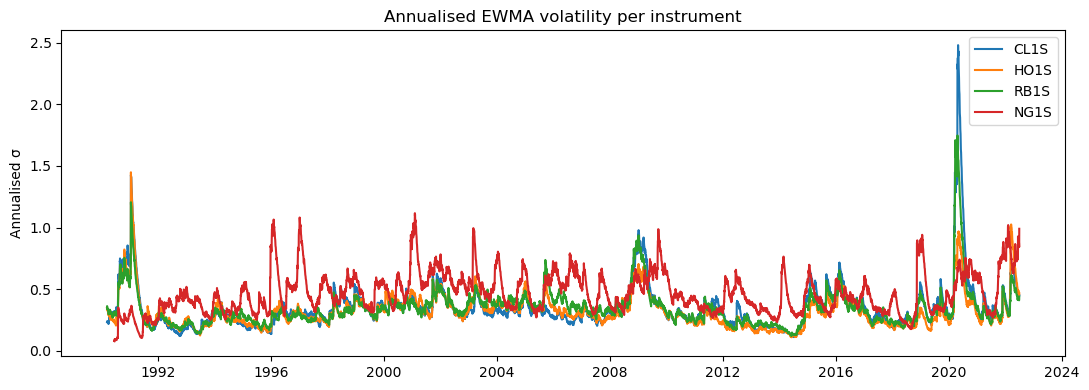

In [38]:
# -----------------------------------------------------------------------------
# CELL 3 — Estimate per-instrument, time-varying volatility (EWMA)
# -----------------------------------------------------------------------------
# "Width of barriers can be based on predicted volatility over the
# interval." We use an EWMA standard deviation of daily log returns, which is
# the standard choice (López de Prado, AFML §3.1, getDailyVol).
#
# Why EWMA rather than rolling std:
#   - Smoothly down-weights older observations.
#   - Responds faster to volatility shocks (very relevant for NG1S in 2022).
#   - Single hyperparameter (span) instead of an arbitrary window cutoff.
#
# We compute this PER INSTRUMENT — energy products have very different
# volatility regimes (NG1S is several times more volatile than CL1S).

def add_ewma_volatility(df, span):
    """
    Add a 'sigma' column: EWMA std of daily log returns, estimated PER INSTRUMENT.
    sigma_t is in 'log-return units' and represents 1-day expected vol.
    """
    df = df.sort_values(["instrument", "date"]).copy()
    # Log returns within each instrument
    df["log_ret"] = (
        df.groupby("instrument")["close"]
          .transform(lambda s: np.log(s).diff())
    )
    # EWMA std within each instrument
    df["sigma"] = (
        df.groupby("instrument")["log_ret"]
          .transform(lambda s: s.ewm(span=span, min_periods=span).std())
    )
    # Floor to avoid degenerate barriers in very calm regimes
    df["sigma"] = df["sigma"].clip(lower=CONFIG["min_sigma"])
    return df

df = add_ewma_volatility(df, span=CONFIG["vol_span"])

# Diagnostic plot: sigma over time per instrument
fig, ax = plt.subplots(figsize=(11, 4))
for inst in CONFIG["instruments"]:
    sub = df[df["instrument"] == inst]
    ax.plot(sub["date"], sub["sigma"] * np.sqrt(252), label=inst.upper())
ax.set_title("Annualised EWMA volatility per instrument")
ax.set_ylabel("Annualised σ")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CONFIG['out_dir']}/sigma_per_instrument.png", dpi=120)
plt.show()

In [39]:
# -----------------------------------------------------------------------------
# CELL 4 — Build the event set
# -----------------------------------------------------------------------------
# An "event" is a day on which the primary signal is non-zero (we want to take
# a trade). We discard signal=0 days because there is no trade to evaluate.
#
# For each event we record:
#   - t0:     entry date
#   - side:   +1 (long) or -1 (short) from the primary signal
#   - p0:     entry price (close of t0; we will discuss timing below)
#   - sigma:  volatility estimate at t0
#
# Timing convention (IMPORTANT for the report):
#   We treat the primary_signal published on date t as something we ACT ON at
#   the close of t — entry price is close(t), and the barrier monitoring starts
#   on day t+1. This is the cleanest assumption and avoids any look-ahead.
#   If your primary model is instead "signal generated at close, traded at next
#   open", swap p0 to open(t+1) and shift accordingly. Document whichever you pick.

def build_events(df):
    """Return one row per (instrument, event) with t0, side, p0, sigma."""
    events = (
        df.loc[
            df["primary_signal"].notna()        # signal must exist (drops pre-2020)
            & (df["primary_signal"] != 0),      # signal must be ±1
            ["date", "instrument", "primary_signal", "close", "sigma"]
        ]
        .rename(columns={"date": "t0",
                         "primary_signal": "side",
                         "close": "p0"})
        .dropna(subset=["sigma"])               # need a vol estimate
        .reset_index(drop=True)
    )
    events["side"] = events["side"].astype(int)
    return events

events = build_events(df)
print(f"Total events: {len(events):,}")
print(events.groupby("instrument").size().rename("events_per_instrument"))
print("\nSide distribution per instrument:")
print(events.groupby(["instrument", "side"]).size().unstack(fill_value=0))
print("\nDate range of events:")
print(events["t0"].agg(["min", "max"]))

Total events: 1,237
instrument
cl1s    422
ho1s     63
ng1s    124
rb1s    628
Name: events_per_instrument, dtype: int64

Side distribution per instrument:
side         -1    1
instrument          
cl1s         36  386
ho1s         10   53
ng1s        124    0
rb1s        261  367

Date range of events:
min   2020-01-03
max   2022-06-30
Name: t0, dtype: datetime64[ns]


In [40]:
# -----------------------------------------------------------------------------
# CELL 5 — The core triple-barrier function
# -----------------------------------------------------------------------------
# For each event we walk forward day-by-day up to horizon_days and check
# whether the SIGNED return path has crossed the profit barrier or the
# stop-loss barrier. We use daily HIGH and LOW (not just close) to detect
# barrier touches — this is the standard trick to mitigate the discretisation
# caveat the lecture flags ("barrier crossing is a discrete event and may miss
# label transitions by a small margin").
#
# Definitions (log returns, since sigma is in log-return units):
#   For a LONG (side=+1):
#       profit barrier hit  if  log(high_t / p0) >=  pt_mult * sigma * sqrt(h)
#       stop-loss hit       if  log(low_t  / p0) <= -sl_mult * sigma * sqrt(h)
#
#   For a SHORT (side=-1):
#       profit barrier hit  if  log(low_t  / p0) <= -pt_mult * sigma * sqrt(h)
#       stop-loss hit       if  log(high_t / p0) >=  sl_mult * sigma * sqrt(h)
#
#   Equivalently, define signed return on bar t as:
#       r_up   = side * log(high_t / p0)  if side=+1, else side * log(low_t / p0)
#       r_down = side * log(low_t  / p0)  if side=+1, else side * log(high_t/ p0)
#   then profit hit ⇔ r_up >= +pt*..., stop hit ⇔ r_down <= -sl*...
#
# Output per event:
#   t1        : date of first barrier hit (or t0 + horizon if none)
#   exit_px   : price used to compute the realised return at exit
#               (= barrier level if a horizontal barrier hit, close(t1) if timeout)
#   ret       : signed log return realised (side * log(exit_px / p0))
#   exit_type : 'pt' | 'sl' | 'vb'   (profit-taking / stop-loss / vertical barrier)
#   meta_label: 1 if profit hit, or if timeout with positive ret; 0 otherwise

def apply_triple_barrier(events, df, pt_mult, sl_mult, horizon_days):
    """
    Returns a DataFrame with one row per event and the columns described above.
    Implemented per instrument, looping events (clear and easy to audit).
    """
    out_rows = []

    # Pre-index OHLC per instrument for fast forward walks
    ohlc_by_inst = {
        inst: g.set_index("date")[["open", "high", "low", "close"]].sort_index()
        for inst, g in df.groupby("instrument")
    }
    sqrt_h = np.sqrt(horizon_days)

    for ev in events.itertuples(index=False):
        if ev.side not in (1, -1):
            continue
        ohlc = ohlc_by_inst[ev.instrument]
        # The future window: bars STRICTLY AFTER t0, up to t0 + horizon_days bars
        # (we monitor from the next bar onwards; entry is at close of t0)
        try:
            i0 = ohlc.index.get_loc(ev.t0)
        except KeyError:
            continue
        window = ohlc.iloc[i0 + 1 : i0 + 1 + horizon_days]
        if len(window) == 0:
            continue

        # Barrier levels in log-return space
        upper = pt_mult * ev.sigma * sqrt_h    # profit if long, loss if short
        lower = -sl_mult * ev.sigma * sqrt_h   # loss if long, profit if short

        # Signed log returns relative to entry
        log_high = np.log(window["high"].values / ev.p0)
        log_low  = np.log(window["low"].values  / ev.p0)
        log_close = np.log(window["close"].values / ev.p0)

        if ev.side == 1:
            r_up, r_down = log_high, log_low
        else:  # side == -1: flip — gains come from price falling
            r_up, r_down = -log_low, -log_high

        # Find the first bar that touches either barrier
        hit_pt = r_up   >=  pt_mult * ev.sigma * sqrt_h
        hit_sl = r_down <= -sl_mult * ev.sigma * sqrt_h

        first_pt = np.argmax(hit_pt) if hit_pt.any() else len(window)
        first_sl = np.argmax(hit_sl) if hit_sl.any() else len(window)

        if first_pt < first_sl:
            exit_idx = first_pt
            exit_type = "pt"
            # Assume the barrier was touched at the barrier level (conservative)
            ret = pt_mult * ev.sigma * sqrt_h
            meta_label = 1
        elif first_sl < first_pt:
            exit_idx = first_sl
            exit_type = "sl"
            ret = -sl_mult * ev.sigma * sqrt_h
            meta_label = 0
        elif first_pt == first_sl and first_pt < len(window):
            # Same bar touched both barriers — ambiguous. Conservative choice:
            # treat as stop-loss (worst case for the trade).
            exit_idx = first_pt
            exit_type = "sl"
            ret = -sl_mult * ev.sigma * sqrt_h
            meta_label = 0
        else:
            # Timeout: take close of the last bar in the window
            exit_idx = len(window) - 1
            exit_type = "vb"
            ret = ev.side * log_close[exit_idx]
            meta_label = int(ret > 0)

        t1 = window.index[exit_idx]
        out_rows.append({
            "t0": ev.t0,
            "t1": t1,
            "instrument": ev.instrument,
            "side": ev.side,
            "p0": ev.p0,
            "sigma": ev.sigma,
            "ret": ret,                    # signed log return
            "exit_type": exit_type,
            "holding_days": exit_idx + 1,  # bars held (>=1)
            "meta_label": meta_label,
        })

    return pd.DataFrame(out_rows)

labels = apply_triple_barrier(
    events, df,
    pt_mult=CONFIG["pt_mult"],
    sl_mult=CONFIG["sl_mult"],
    horizon_days=CONFIG["horizon_days"],
)
print(labels.head())
print(f"\nLabels produced: {len(labels):,}")

          t0         t1 instrument  side         p0     sigma       ret  \
0 2020-01-07 2020-01-08       cl1s    -1  25.411618  0.016380  0.051798   
1 2020-01-22 2020-01-27       cl1s    -1  22.984255  0.017435  0.055133   
2 2020-01-23 2020-01-27       cl1s    -1  22.518412  0.017491  0.055312   
3 2020-01-24 2020-01-31       cl1s    -1  21.951300  0.017743  0.056108   
4 2020-01-27 2020-02-03       cl1s    -1  21.525966  0.017688  0.055934   

  exit_type  holding_days  meta_label  
0        pt             1           1  
1        pt             3           1  
2        pt             2           1  
3        pt             5           1  
4        pt             5           1  

Labels produced: 1,235


In [41]:
# -----------------------------------------------------------------------------
# CELL 6 — Diagnostic checks on the labels
# -----------------------------------------------------------------------------

def label_diagnostics(labels):
    rows = []
    for inst, g in labels.groupby("instrument"):
        rows.append({
            "instrument": inst,
            "n_events": len(g),
            "base_rate_meta=1": g["meta_label"].mean(),
            "frac_pt":  (g["exit_type"] == "pt").mean(),
            "frac_sl":  (g["exit_type"] == "sl").mean(),
            "frac_vb":  (g["exit_type"] == "vb").mean(),
            "avg_holding_days": g["holding_days"].mean(),
            "n_long":  (g["side"] ==  1).sum(),
            "n_short": (g["side"] == -1).sum(),
        })
    return pd.DataFrame(rows).set_index("instrument").round(3)

diag = label_diagnostics(labels)
print(diag)
diag.to_csv(f"{CONFIG['out_dir']}/label_diagnostics.csv")

            n_events  base_rate_meta=1  frac_pt  frac_sl  frac_vb  \
instrument                                                          
cl1s             421             0.682    0.283    0.221    0.496   
ho1s              63             0.651    0.302    0.222    0.476   
ng1s             124             0.597    0.387    0.177    0.435   
rb1s             627             0.510    0.290    0.270    0.440   

            avg_holding_days  n_long  n_short  
instrument                                     
cl1s                   7.587     385       36  
ho1s                   7.317      53       10  
ng1s                   7.540       0      124  
rb1s                   7.313     366      261  


In [42]:
# -----------------------------------------------------------------------------
# CELL 7 — Diagnostic: distribution of primary-signal run lengths
# -----------------------------------------------------------------------------
# Sanity check for the choice of horizon_days. We look at how long the primary
# model typically wants to hold a position (consecutive days of same sign).
# Our horizon should be in the same ball-park.

def signal_run_lengths(df):
    rows = []
    for inst, g in df.groupby("instrument"):
        s = g.sort_values("date")["primary_signal"].values
        runs = []
        cur, n = s[0], 1
        for x in s[1:]:
            if x == cur and x != 0:
                n += 1
            else:
                if cur != 0:
                    runs.append(n)
                cur, n = x, 1
        if cur != 0:
            runs.append(n)
        rows.append({
            "instrument": inst,
            "median_run": int(np.median(runs)) if runs else 0,
            "p75_run":    int(np.percentile(runs, 75)) if runs else 0,
            "max_run":    int(np.max(runs)) if runs else 0,
        })
    return pd.DataFrame(rows).set_index("instrument")

print("Primary-signal run-length stats per instrument:")
print(signal_run_lengths(df))

Primary-signal run-length stats per instrument:
            median_run  p75_run  max_run
instrument                              
cl1s                 1        1       71
ho1s                 1        1       11
ng1s                 1        1       40
rb1s                 1        1      129


In [43]:
# -----------------------------------------------------------------------------
# CELL 8 — Sample weights via average uniqueness
# -----------------------------------------------------------------------------
# Fixes vs. previous version:
#   1. Use pd.DatetimeIndex.get_loc for date→index lookup (handles dtype/precision).
#   2. Restrict the date axis to dates that appear in the labels (no need for
#      the full 1990+ history per instrument; labels start in 2020).
#   3. Defensive check: skip events whose t0/t1 don't fall on a known bar.

def avg_uniqueness_weights(labels, df):
    out = []
    for inst, g in labels.groupby("instrument"):
        # Use a DatetimeIndex restricted to the label window — fast and robust.
        inst_dates = pd.to_datetime(
            df.loc[df["instrument"] == inst, "date"]
        ).sort_values().unique()
        date_idx = pd.DatetimeIndex(inst_dates)

        concurrent = np.zeros(len(date_idx), dtype=np.float64)
        spans = []
        for r in g.itertuples(index=False):
            t0, t1 = pd.Timestamp(r.t0), pd.Timestamp(r.t1)
            try:
                i0 = date_idx.get_loc(t0)
                i1 = date_idx.get_loc(t1)
            except KeyError:
                # Defensive: event endpoints must exist in the OHLC calendar.
                spans.append(None)
                continue
            concurrent[i0:i1 + 1] += 1.0
            spans.append((i0, i1))

        # Inverse-concurrency averaged over each event's span.
        u = np.array([
            np.mean(1.0 / concurrent[i0:i1 + 1]) if s is not None else np.nan
            for s, (i0, i1) in zip(spans, [s if s is not None else (0, 0) for s in spans])
        ])

        # Replace NaNs (skipped events) with the mean so they don't break fitting.
        if np.isnan(u).any():
            u = np.where(np.isnan(u), np.nanmean(u), u)

        # Normalise so weights average to 1.
        w = u / u.mean() if u.mean() > 0 else u

        sub = g.copy()
        sub["sample_weight"] = w
        out.append(sub)

    return pd.concat(out, ignore_index=True)


labels = avg_uniqueness_weights(labels, df)
print(labels[["instrument", "t0", "t1", "meta_label", "sample_weight"]].head())
print("\nSample-weight summary per instrument:")
print(labels.groupby("instrument")["sample_weight"].describe().round(3))

  instrument         t0         t1  meta_label  sample_weight
0       cl1s 2020-01-07 2020-01-08           1       6.020632
1       cl1s 2020-01-22 2020-01-27           1       3.135746
2       cl1s 2020-01-23 2020-01-27           1       2.174117
3       cl1s 2020-01-24 2020-01-31           1       1.538606
4       cl1s 2020-01-27 2020-02-03           1       1.404814

Sample-weight summary per instrument:
            count  mean    std    min    25%    50%    75%    max
instrument                                                       
cl1s        421.0   1.0  0.712  0.547  0.630  0.774  1.084  6.021
ho1s         63.0   1.0  0.650  0.291  0.500  0.769  1.390  2.518
ng1s        124.0   1.0  0.745  0.428  0.564  0.743  1.109  4.711
rb1s        627.0   1.0  0.452  0.698  0.725  0.834  1.036  3.999


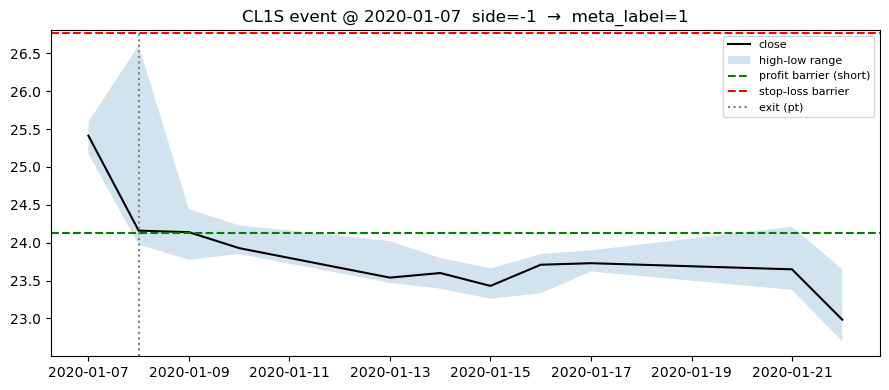

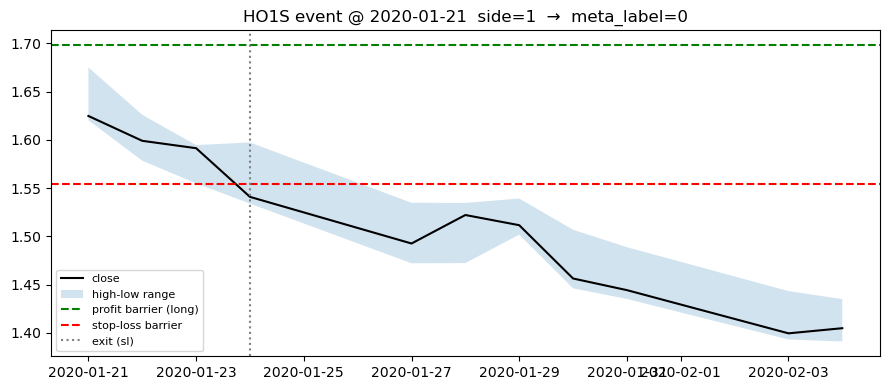

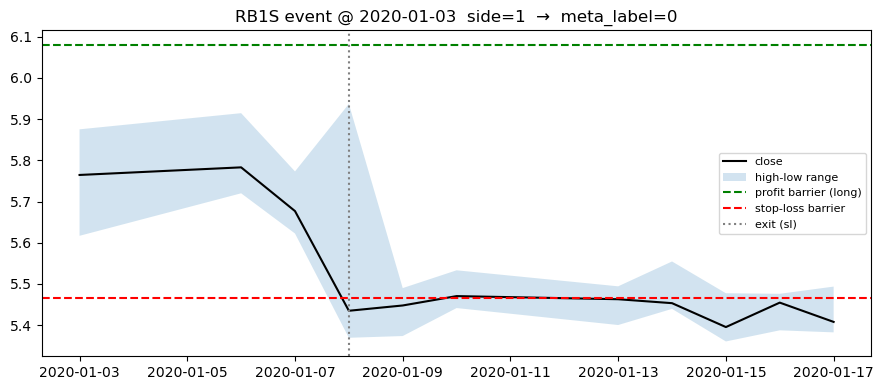

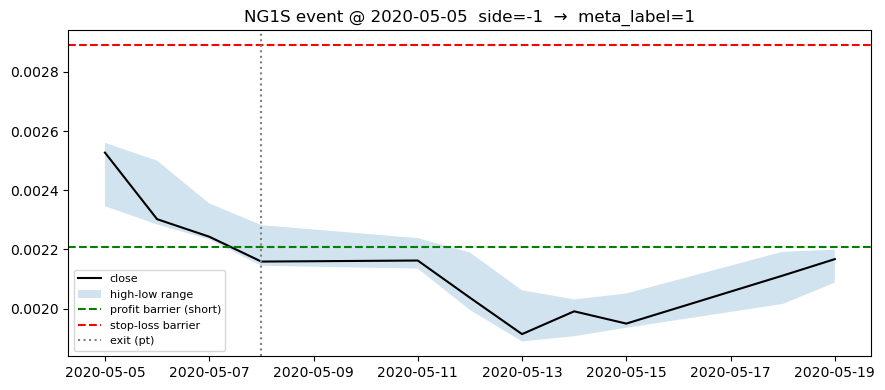

In [44]:
# -----------------------------------------------------------------------------
# CELL 9 — Visualise one event per instrument (sanity / report figure)
# -----------------------------------------------------------------------------
# A picture of the barrier mechanism on a real event is worth a paragraph.

def plot_event_example(inst, df, labels, n_show=1):
    # Only consider rows with no NaNs in the columns we need.
    needed = ["t0", "t1", "side", "p0", "sigma", "exit_type", "meta_label"]
    sub = (
        labels[labels["instrument"] == inst]
        .dropna(subset=needed)
        .head(n_show)
    )
    if sub.empty:
        print(f"[{inst}] no clean event to plot — check upstream NaNs.")
        return

    ohlc = df[df["instrument"] == inst].set_index("date")

    for r in sub.itertuples(index=False):
        # Coerce to plain Python types up front so f-strings can't fail.
        side       = int(r.side)
        meta_label = int(r.meta_label)
        sigma      = float(r.sigma)
        p0         = float(r.p0)
        t0         = pd.Timestamp(r.t0)
        t1         = pd.Timestamp(r.t1)

        try:
            i0 = ohlc.index.get_loc(t0)
        except KeyError:
            print(f"[{inst}] t0={t0.date()} not in OHLC calendar — skipping.")
            continue

        window = ohlc.iloc[i0 : i0 + CONFIG["horizon_days"] + 1]
        if window.empty:
            continue

        sqrt_h = np.sqrt(CONFIG["horizon_days"])
        # Note: the *price-space* barriers depend on side via exp(side * ...).
        upper = p0 * np.exp( CONFIG["pt_mult"] * sigma * sqrt_h * side)
        lower = p0 * np.exp(-CONFIG["sl_mult"] * sigma * sqrt_h * side)

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(window.index, window["close"], label="close", color="black")
        ax.fill_between(window.index, window["low"], window["high"],
                        alpha=0.2, label="high-low range")
        ax.axhline(upper, color="green", ls="--",
                   label=f"profit barrier ({'long' if side == 1 else 'short'})")
        ax.axhline(lower, color="red", ls="--", label="stop-loss barrier")
        ax.axvline(t1, color="grey", ls=":", label=f"exit ({r.exit_type})")
        ax.set_title(
            f"{inst.upper()} event @ {t0.date()}  "
            f"side={side}  →  meta_label={meta_label}"
        )
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(
            f"{CONFIG['out_dir']}/event_{inst}_{t0.date()}.png",
            dpi=120,
        )
        plt.show()


for inst in CONFIG["instruments"]:
    plot_event_example(inst, df, labels, n_show=1)

In [45]:
n_before = len(labels)
labels = labels.dropna(subset=["meta_label", "side", "t1"]).copy()
labels["meta_label"] = labels["meta_label"].astype(int)
labels["side"] = labels["side"].astype(int)
print(f"Dropped {n_before - len(labels)} NaN rows. Final: {len(labels):,}")

Dropped 0 NaN rows. Final: 1,235


In [46]:
# -----------------------------------------------------------------------------
# CELL 10 — Save the labels file for downstream sections
# -----------------------------------------------------------------------------
# Final columns the rest of the project consumes:
#   t0, t1, instrument, side, p0, sigma, ret, exit_type, holding_days,
#   meta_label, sample_weight

final_cols = ["t0", "t1", "instrument", "side", "p0", "sigma",
              "ret", "exit_type", "holding_days",
              "meta_label", "sample_weight"]
labels = labels[final_cols].sort_values(["instrument", "t0"]).reset_index(drop=True)

out_path = Path(CONFIG["out_dir"]) / "triple_barrier_labels.csv"
labels.to_csv(out_path, index=False)
print(f"Saved {len(labels):,} labels → {out_path}")
print("\nClass balance per instrument:")
print(labels.groupby("instrument")["meta_label"].agg(["mean", "count"]))

Saved 1,235 labels → outputs/labels/triple_barrier_labels.csv

Class balance per instrument:
                mean  count
instrument                 
cl1s        0.681710    421
ho1s        0.650794     63
ng1s        0.596774    124
rb1s        0.510367    627


In [47]:
# -----------------------------------------------------------------------------
# CELL 11 — (Recommended) Sensitivity analysis to put in the report
# -----------------------------------------------------------------------------
# Quick grid over (pt, sl, h). The marking rubric explicitly asks you to
# JUSTIFY your barrier widths and time-limit — running this grid is the
# evidence. Pick the configuration that gives a sensible balance of pt/sl/vb
# exits and a base rate that's neither degenerate (~0 or ~1) nor uninformative.

def sensitivity(df, events, grid):
    rows = []
    for pt, sl, h in grid:
        lab = apply_triple_barrier(events, df, pt, sl, h)
        for inst, g in lab.groupby("instrument"):
            rows.append({
                "pt": pt, "sl": sl, "h": h, "instrument": inst,
                "base_rate": g["meta_label"].mean(),
                "frac_pt": (g["exit_type"] == "pt").mean(),
                "frac_sl": (g["exit_type"] == "sl").mean(),
                "frac_vb": (g["exit_type"] == "vb").mean(),
                "n": len(g),
            })
    return pd.DataFrame(rows)

grid = [
    (1.0, 1.0, 5),
    (1.0, 1.0, 10),
    (1.0, 1.0, 20),
    (1.5, 1.0, 10),   # asymmetric: wider profit target
    (2.0, 1.0, 10),
    (1.0, 1.5, 10),   # asymmetric: tighter profit, wider stop (rarely useful)
]
sens = sensitivity(df, events, grid).round(3)
print(sens.pivot_table(index=["pt", "sl", "h"], columns="instrument",
                      values="base_rate"))
sens.to_csv(f"{CONFIG['out_dir']}/sensitivity.csv", index=False)

instrument   cl1s   ho1s   ng1s   rb1s
pt  sl  h                             
1.0 1.0 5   0.644  0.603  0.524  0.514
        10  0.682  0.651  0.597  0.510
        20  0.658  0.571  0.669  0.469
    1.5 10  0.708  0.667  0.613  0.530
1.5 1.0 10  0.665  0.619  0.581  0.483
2.0 1.0 10  0.663  0.619  0.581  0.475
